<a href="https://colab.research.google.com/github/itzelgabrielaroquedelgado076-cell/Estad-stica2025B/blob/main/UNIDAD5_PROBLEMARIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problemario de bloqueo

##Problema 1:
Se hace un estudio sobre la efectividad de tres marcas de atomizador para matar moscas. Para ello, cada producto se aplica a un grupo de 100 moscas, y se cuenta el número de moscas muertas expresado en porcentajes. Se hicieron seis réplicas, pero en días diferentes; por ello, se sospecha que puede haber algún efecto importante debido a esta fuente de variación. Los datos obtenidos se muestran a continuación:

| Marca de atomizador | Réplica 1 | Réplica 2 | Réplica 3 | Réplica 4 | Réplica 5 | Réplica 6 |
|----------------------|-----------|-----------|-----------|-----------|-----------|-----------|
| 1                   | 72        | 65        | 67        | 75        | 62        | 73        |
| 2                   | 55        | 59        | 68        | 70        | 53        | 50        |
| 3                   | 64        | 74        | 61        | 58        | 51        | 69        |

**Preguntas:**<br>
a) Suponiendo un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
b) ¿Existe diferencia entre la efectividad promedio de los atomizadores?  
c) ¿Hay algún atomizador mejor? Argumente su respuesta.  
d) ¿Hay diferencias significativas en los resultados de diferentes días en que se realizó el experimento? Argumente su respuesta.  
e) Verifique los supuestos de normalidad y de igual varianza entre las marcas.


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
marca,replica,porcentaje
M1,R1,72
M1,R2,65
M1,R3,67
M1,R4,75
M1,R5,62
M1,R6,73
M2,R1,55
M2,R2,59
M2,R3,68
M2,R4,70
M2,R5,53
M2,R6,50
M3,R1,64
M3,R2,74
M3,R3,61
M3,R4,58
M3,R5,51
M3,R6,69
'''



df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,marca,replica,porcentaje
0,M1,R1,72
1,M1,R2,65
2,M1,R3,67
3,M1,R4,75
4,M1,R5,62
5,M1,R6,73
6,M2,R1,55
7,M2,R2,59
8,M2,R3,68
9,M2,R4,70


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# Ho: Todas las marcas de atomizador para matar moscas tienen el mismo efecto.
# H1: Al menos una marca de atomizador para matar moscas tiene un efecto distinto.
# H0: Todas las replicas realizadas en los días son iguales
# H1: Al menos una replica realizada en los días es diferente.

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'porcentaje~ C(marca) + C(replica)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(marca),296.333333,2.0,2.880752,0.102804
C(replica),281.333333,5.0,1.093973,0.420718
Residual,514.333333,10.0,NaN,NaN


valor-p (Shapiro) = 0.5541005255267678


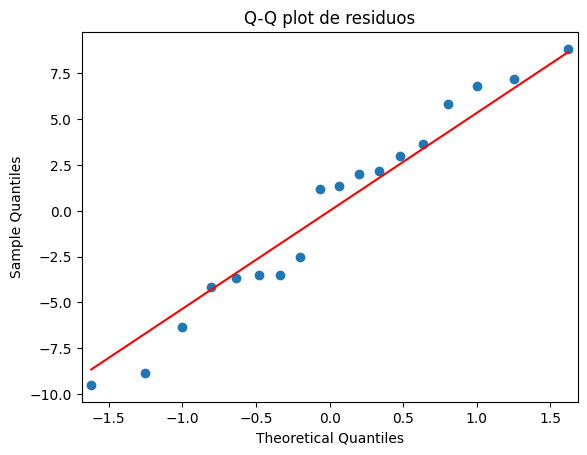

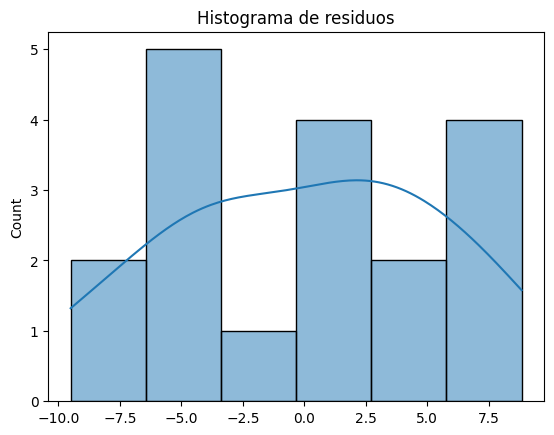

In [ ]:
#Ho: Normalidad
#H1: No hay normalidad

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['marca'] == 'M1']['porcentaje']
grupo2 = df[df['marca'] == 'M2']['porcentaje']
grupo3 = df[df['marca'] == 'M3']['porcentaje']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.5999140287120529


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(marca)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.271


**Preguntas:**

a) Suponiendo un DBCA, formule las hipótesis adecuadas y el modelo estadístico.

Ho:Todas las marcas de atomizador para matar moscas tienen el mismo efecto.

H1:Al menos una marca de atomizador para matar moscas tiene un efecto distinto.

H0: Todas las replicas realizadas en los días son iguales.

H1: Al menos una replica realizada en los días es diferente.

El modelo estadístico que se utilizó fue el ANOVA, el cual nos indicó que no hay diferencia significativa en la marca de atomizadores siendo el mismo caso en las replicas donde de la misma manera no hay diferencia en estas.

b) ¿Existe diferencia entre la efectividad promedio de los atomizadores?

No hay evidencia estadística para afirmar que existe diferencia entre la efectividad promedio de los atomizadores ya que el valor-p obtenido es 0.102804 siendo mayor al nivel de significancia de 0.05, lo que significa que no se rechaza la hipótesis nula por lo tanto no hay diferencia significativa entre la efectividad promedio de los atomizadores ya que todas las marcas de atomizador para matar moscas tienen el mismo efecto.


c) ¿Hay algún atomizador mejor? Argumente su respuesta.

Dado que en el ANOVA no se rechazo la hipótesis nula no se puede afirmar que alguno de los atomizadores es mejor ya que en estos no hay diferencia significativa lo que nos indica que los atomizadores son iguales ya que no se rechazó la hipótesis nula planteada al inició de que todas las marcas de atomizador para matar moscas tienen el mismo efecto.

d) ¿Hay diferencias significativas en los resultados de diferentes días en que se realizó el experimento? Argumente su respuesta.

No hay diferencias significativas en los resultados de diferentes días en los que se realizó el expermiento, ya que el modelo ANOVA nos arrojo un valor-p de 0.420718 en el que este es mayor al nivel de significancia de 0.05 por lo que, no se rechaza la hipótesis nula y esto significa que todas las replicas realizadas en los días son iguales.

e) Verifique los supuestos de normalidad y de igual varianza entre las marcas.

La prueba de Shapiro confirma que si hay normalidad y la prueba de Levene nos indica varianzas iguales entre las marcas, por lo que el análisis del modelo ANOVA es válido y las conclusiones obtenidas son de la misma manera válidas en el que además el eta cuadrado obtenido de 0.271 nos indica que el 27.1% del porcentaje se puede explicar por la vaibilidad de la marca de atomizador para matar moscas por lo que el efecto de esta es grande pero también implica que existen otros factores dentro del 72.9% que influyen en la efectividad o el efecto del atomizador .

##Problema 2:
En una empresa lechera se tienen varios silos para almacenar leche (cisternas de 60 000 L). Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. Se sospecha que en algunos silos hay problemas, por ello, durante cinco días se decide registrar la temperatura a cierta hora crítica. Obviamente la temperatura de un día a otro es una fuente de variabilidad que podría impactar la variabilidad total.

| Silo | Lunes | Martes | Miércoles | Jueves | Viernes |
|------|-------|--------|-----------|--------|---------|
| A    | 4.0   | 4.0    | 5.0       | 0.5    | 3.0     |
| B    | 5.0   | 6.0    | 2.0       | 4.0    | 4.0     |
| C    | 4.5   | 4.0    | 3.5       | 2.0    | 3.0     |
| D    | 2.5   | 4.0    | 6.5       | 4.5    | 4.0     |
| E    | 4.0   | 4.0    | 3.5       | 2.0    | 4.0     |

**Preguntas:**<br>
a) En este problema, ¿cuál es el factor de tratamiento y cuál el factor de bloque?  
b) Suponga un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
c) ¿Hay diferencia entre los silos?  
d) ¿La temperatura de un día a otro es diferente?  
e) Revise residuos, ¿hay algún problema evidente?


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
silo,dia,temperatura
A1,lunes,4.0
A1,martes,4.0
A1,miercoles,5.0
A1,jueves,0.5
A1,viernes,3.0
B2,lunes,5.0
B2,martes,6.0
B2,miercoles,2.0
B2,jueves,4.0
B2,viernes,4.0
C3,lunes,4.5
C3,martes,4.0
C3,miercoles,3.5
C3,jueves,2.0
C3,viernes,3.0
D4,lunes,2.5
D4,martes,4.0
D4,miercoles,6.5
D4,jueves,4.5
D4,viernes,4.0
E5,lunes,4.0
E5,martes,4.0
E5,miercoles,3.5
E5,jueves,2.0
E5,viernes,4.0
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,silo,dia,temperatura
0,A1,lunes,4.0
1,A1,martes,4.0
2,A1,miercoles,5.0
3,A1,jueves,0.5
4,A1,viernes,3.0
5,B2,lunes,5.0
6,B2,martes,6.0
7,B2,miercoles,2.0
8,B2,jueves,4.0
9,B2,viernes,4.0


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05

# H0: Todos los silos tienen temperaturas de almacenamiento iguales.
# H1: Al menos un silo tiene una temperatura de almacenamiento distinta.

# H0: Todos los días la temperatura es igual
# H1: Al menos un día la temperatura es distinta.



# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'temperatura~ C(silo) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(silo),4.46,4.0,0.690402,0.609212
C(dia),9.76,4.0,1.510836,0.246022
Residual,25.84,16.0,NaN,NaN


valor-p (Shapiro) = 0.1527850137871632


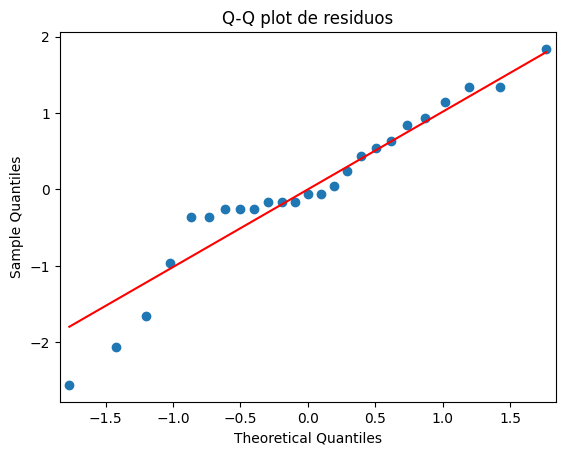

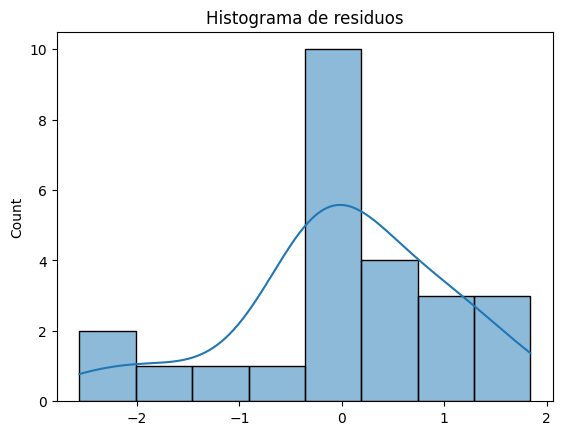

In [ ]:
#Ho: Normalidad
#H1: No hay normalidad

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['silo'] == 'A1']['temperatura']
grupo2 = df[df['silo'] == 'B2']['temperatura']
grupo3 = df[df['silo'] == 'C3']['temperatura']
grupo4 = df[df['silo'] == 'D4']['temperatura']
grupo5 = df[df['silo'] == 'E5']['temperatura']

stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.8915311038595306


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(silo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.111


**Preguntas:**

a) En este problema, ¿cuál es el factor de tratamiento y cuál el factor de bloque?

El factor de tratamiento son los silos debido a que es lo que se quiere comparar,es decir, si hay diferencias en la temperatura de almacenamiento entre cada uno de estos. El factor de bloque es el día ya que es necesario aislar la variación provocada por las condiciones diarias perminitiendo así comparar de manera correcta los asilos ya que si no es así el modelo o el análisis podría interpretar la variación como diferencias entre los silos.

b) Suponga un DBCA, formule las hipótesis adecuadas y el modelo estadístico.

H0: Todos los silos tienen temperaturas de almacenamiento iguales.

H1: Al menos un silo tiene una temperatura de almacenamiento distinta.

H0: Todos los días la temperatura es igual

H1: Al menos un día la temperatura es distinta.

El modelo estadistico que se utilizo fue el ANOVA, el cual nos demostró que los silos no tienen diferencia significativa siendo el mismo caso para los días de registro de registró de la temperatura.


c) ¿Hay diferencia entre los silos?

No, no hay diferencia significativa entre los silos ya que el valor obtenido en el modelo ANOVA es de 0.609212 y al ser mayor al nivel de significancia nos indica que no se rechaza la hipótesis nula lo que quiere decir que, todos los silos tienen temperaturas de almacenamiento iguales.

d) ¿La temperatura de un día a otro es diferente?

No, esta no es diferente porque el valor-p obtenido en el ANOVA nos indica que no hay diferencia estadística debido a que no se rechaza la hipótesis nula por lo que todos los días .

e) Revise residuos, ¿hay algún problema evidente?

No, no hay ningún problema evidente ya que el test de shapiro nos arrojó un valor-p de 0.152785, el cual es mayor al nivel de significancia de 0.05, por lo que no se rechaza la hipótesis nula de normalidad; esto nos indica que los residuos siguen una distribución normal y no hay evidencia de que haya problemas de normalidad; además es posible afirmar que no hay algún problema evidente con el estadístico de levene ya que este nos arroja que si hay homoscedasticidad, es decir, que las varianzas entre silos no son diferentes por lo que debido a lo anterior el modelo de ANOVA se cumple y este es confiable donde la misma manera es posible observar conforme el valor de eta el cual nos indica que el 11.1% de la variabilidad temperatura se puede explicar por la varibilidad del silo y del modelo reflejando un efecto moderado por lo que esto inidca que el silo influye en la temperatura aunque existen otros factores que se encuentran dentro del porcentaje restante.



## Problema 3
Se diseñó un experimento para estudiar el rendimiento de cuatro detergentes. Las siguientes lecturas de “blancura” se obtuvieron con un equipo especial diseñado para 12 cargas de lavado, distribuidas en tres modelos de lavadoras:

| Detergente | Lavadora 1 | Lavadora 2 | Lavadora 3 |
|------------|------------|------------|------------|
| A          | 45         | 43         | 51         |
| B          | 47         | 44         | 52         |
| C          | 50         | 49         | 57         |
| D          | 42         | 37         | 49         |

**Preguntas:**<br>
a) Señale el nombre del diseño experimental utilizado.  
b) Formule la hipótesis que se quiere probar en este problema.  
c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.  



In [ ]:
import pandas as pd
from io import StringIO

datos = '''
detergente,lavadora,blancura
A,Lavadora1,45
A,Lavadora2,43
A,Lavadora3,51
B,Lavadora1,47
B,Lavadora2,44
B,Lavadora3,52
C,Lavadora1,50
C,Lavadora2,49
C,Lavadora3,57
D,Lavadora1,42
D,Lavadora2,37
D,Lavadora3,49
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,detergente,lavadora,blancura
0,A,Lavadora1,45
1,A,Lavadora2,43
2,A,Lavadora3,51
3,B,Lavadora1,47
4,B,Lavadora2,44
5,B,Lavadora3,52
6,C,Lavadora1,50
7,C,Lavadora2,49
8,C,Lavadora3,57
9,D,Lavadora1,42


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los detergentes tienen rendimientos iguales.
# H1: Al menos un detergente tiene un rendimiento distinto.

# H0: Todas las lavadoras tienen lecturas de blancura iguales.
# H1: Al menos una lavadora tiene una lectura de blancura distinta.


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'blancura~ C(detergente) + C(lavadora)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(detergente),133.666667,3.0,34.127660,0.000363
C(lavadora),170.166667,2.0,65.170213,0.000085
Residual,7.833333,6.0,NaN,NaN


valor-p (Shapiro) = 0.8945576994890372


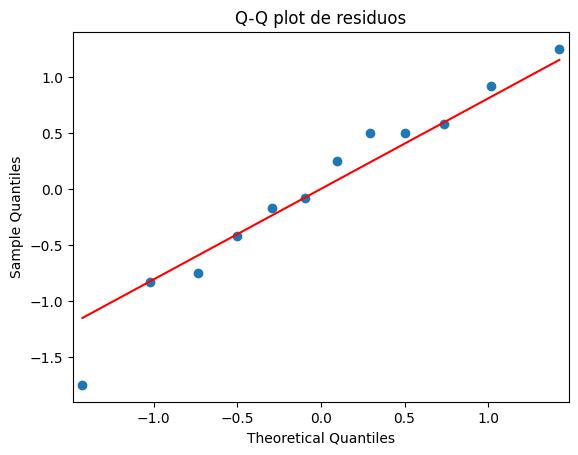

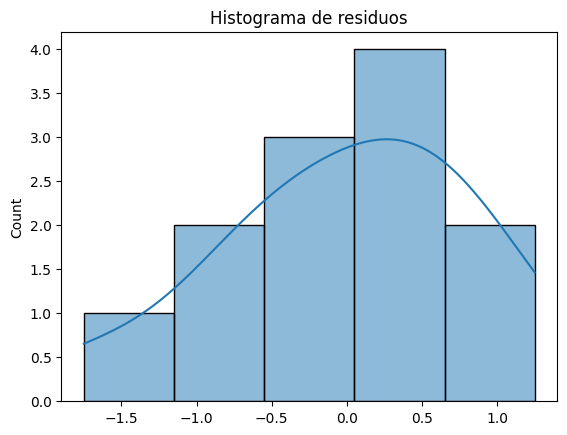

In [ ]:
#Ho: Normalidad
#H1: No hay normalidad

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['detergente'] == 'A']['blancura']
grupo2 = df[df['detergente'] == 'B']['blancura']
grupo3 = df[df['detergente'] == 'C']['blancura']
grupo4 = df[df['detergente'] == 'D']['blancura']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.9432760038375858


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   1.3333 0.9847 -11.0002 13.6669  False
     A      C   5.6667  0.495  -6.6669 18.0002  False
     A      D  -3.6667  0.779 -16.0002  8.6669  False
     B      C   4.3333 0.6855  -8.0002 16.6669  False
     B      D     -5.0 0.5887 -17.3336  7.3336  False
     C      D  -9.3333 0.1495 -21.6669  3.0002  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

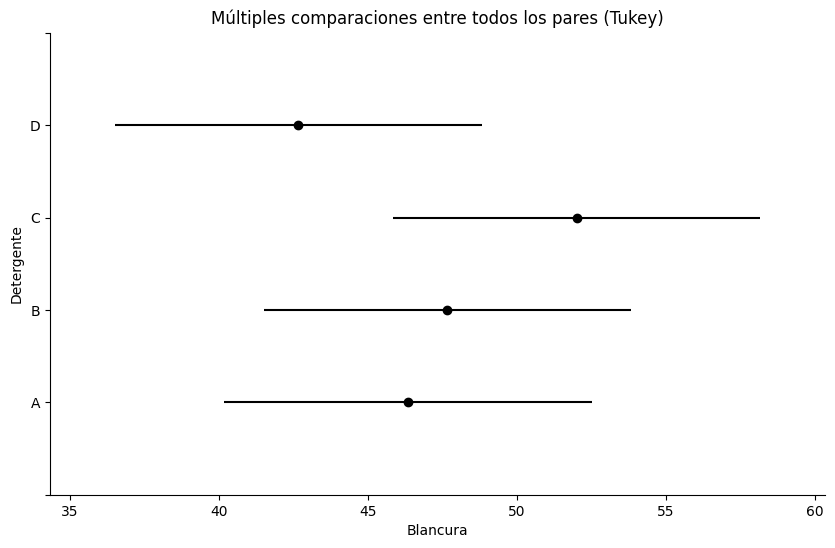

In [ ]:
#PARA APLICAR ESTA ES NECESARIO QUE SE CUMPLA EL ESTADISTICO DE SHAPIRO Y EL TEST DE LEVENE
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['blancura'], groups=df['detergente'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Detergente", xlabel="Blancura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
Lavadora1 Lavadora2    -2.75 0.6063 -10.5781  5.0781  False
Lavadora1 Lavadora3     6.25 0.1192  -1.5781 14.0781  False
Lavadora2 Lavadora3      9.0 0.0261   1.1719 16.8281   True
-----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

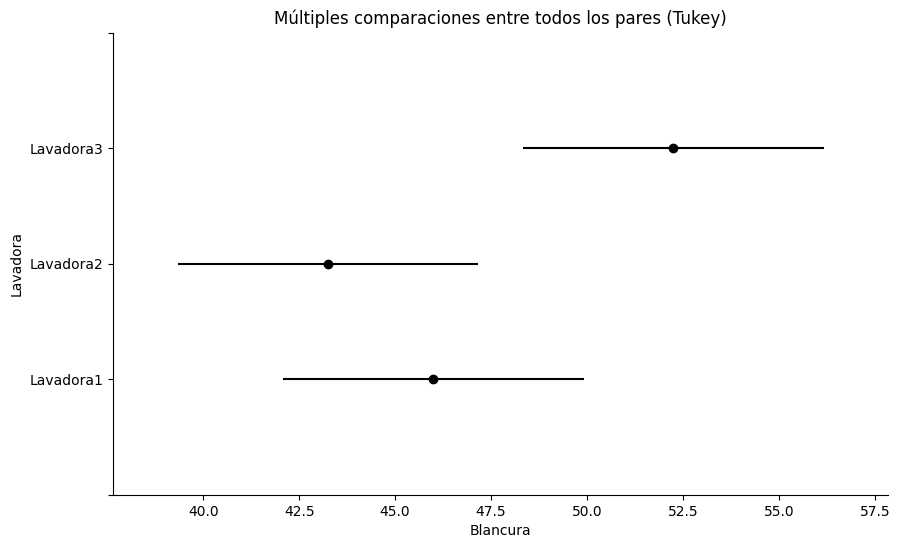

In [ ]:
#PARA APLICAR ESTA ES NECESARIO QUE SE CUMPLA EL ESTADISTICO DE SHAPIRO Y EL TEST DE LEVENE
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['blancura'], groups=df['lavadora'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Lavadora", xlabel="Blancura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(detergente)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.429


**Preguntas:**

a) Señale el nombre del diseño experimental utilizado.

El diseño experimental utilizado es el Diseño en Bloques Completos al Azar (DBCA) porque cada detergente fue probado en cada lavadora por lo que los detergentes son los tratamientos que se quieren comparar y las lavadoras son el factor bloque debido a que estas pueden generar diferencias en la blancura y al emplearlas como bloque para separa la varibilidad que estas generán y que no provienen de los detergentes y al aplicarlo así no se mezclarán con el efecto del detergente.

b) Formule la hipótesis que se quiere probar en este problema.

H0: Todos los detergentes tienen rendimientos iguales.

H1: Al menos un detergente tiene un rendimiento distinto.

H0: Todas las lavadoras tienen lecturas de blancura iguales.

H1: Al menos una lavadora tiene una lectura de blancura distinta.

c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.

Conforme el modelo ANOVA se puede concluir que si hay diferencia significativa entre los detergentes ya que el valor-p obtenido de 0.000363 es menor al nivel de significancia de 0.05 lo que nos indica que se rechaza la hipótesis nula y se acepta la alternativa la cual es que al menos un detergente tiene un rendimiento distinto siendo el mismo caso para las lavadoras donde el valor-p obtenido en este factor es de la misma manera menor al nivel de significancia y nos indica que si hay diferencia significativa lo que significa que al menos una lavadora tiene una lectura de blancura distinta, es decir, cada lavadora produce niveles distintos de blancura, probablemente por diferencias que tienen cada una de estas; por lo que con lo anterior es posible deducir que existe un efecto significativo tanto del tipo de detergente como de la lavadora sobre la blancura, lo que significa que los detergentes no producen el mismo rendimiento, en el que asimismo como el efecto de las lavadoras resultó significativo esto nos indica que cada lavadora aporto su variabilidad por lo que al aplicar el bloque en las lavadoras nos permitió aislar la variación que proviene de los modelos de las lavadoras haciendo así que fuera más preciso el obtener el efecto que tienen los detergentes en la blancura deduciendo que la blancura depende del tipo de detergente ya que esta cambia cuando el detergente cambia. Al aplicar la prueba de tuckey esta nos muestra que en las combinaciones de los grupos de detergente no hay diferencia significativa ya que el valor-p ajustado es mayor al nivel de significancia y esto nos indica que aunque las medias de blancura se ven diferentes a simple vista, esas diferencias no son lo bastante grandes como para decir que realmente son distintas una vez que se toma en cuenta que cada lavadora funciona diferente; por lo que, no podemos asegurar que un detergente sea mejor que los otros en cuanto a la blancura que produce en este experimento y apesar de que el detergente C tienen una mayor blancura entre los cuatro detergentes, la prueba de Tukey nos indica que estas diferencias no son estadísticamente significativas; por lo tanto, aunque C muestra una mayor blancura, no se puede afirmar que sea superior o tenga un mejor rendimiento que los demás ya que no hay diferencia significativa entre estos pero en este caso ANOVA es el que manda y esta nos indica que si hay diferencia aunque de manera débil por lo que el C si se puede considerar como el detergente que tienen una mejor blancura en donde el D tiene una menor y para el caso de las lavadoras la prueba tuckey nos permite observar donde hay diferencias donde esposible observar que la lavadora 3 ofrece un nivel de blancura mayor siendo además la que tienen una diferencia con la lavadora 2 por lo que es posible observar que además la lavadora también influye para obtener una blancura mayor.

Además conforme los valores obtenidos en el test de shapiro y levene es posible concluir que el ANOVA es válido y asimismo es confiable ya que cada uno de los supuestos de normalidad y homoscedasticidad se cumplieron debido a que el valor-p obtenido en ambos es mayor al nivel de significancia de 0.05 por lo que no se rechazan las hipótesis nulas establecidas anteriormente en cada apartado.

Mientras que el valor obtenido en el eta cuadrado de 0.429 nos indica que el 42.9% de la variabilidad en la blancura se puede explicar por la variabilidad del detergente por lo que el efecto de esta es moderado a grande lo que nos indica que el detergente influye de manera moderada a fuerte en la blancura, mientras que el 57.1% restante se debe a otros factores.





## Problema 4
Con respecto al problema anterior:<br>
a) Conteste los tres incisos del problema anterior sin tomar en cuenta el efecto de las lavadoras y obtenga conclusiones.  
b) ¿Hay diferencias en las conclusiones anteriores y las del problema anterior? Explique su respuesta.  
c) ¿Con cuáles conclusiones se queda? Explique su respuesta.

In [ ]:
import pandas as pd
from io import StringIO

datos = '''
detergente,blancura
A,45
A,43
A,51
B,47
B,44
B,52
C,50
C,49
C,57
D,42
D,37
D,49
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.

,detergente,blancura
0,A,45
1,A,43
2,A,51
3,B,47
4,B,44
5,B,52
6,C,50
7,C,49
8,C,57
9,D,42


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los detergentes tienen rendimientos iguales.
# H1: Al menos un detergente tiene un rendimiento distinto


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'blancura~ C(detergente)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(detergente),133.666667,3.0,2.002497,0.19229
Residual,178.000000,8.0,NaN,NaN


valor-p (Shapiro) = 0.14533139517179772


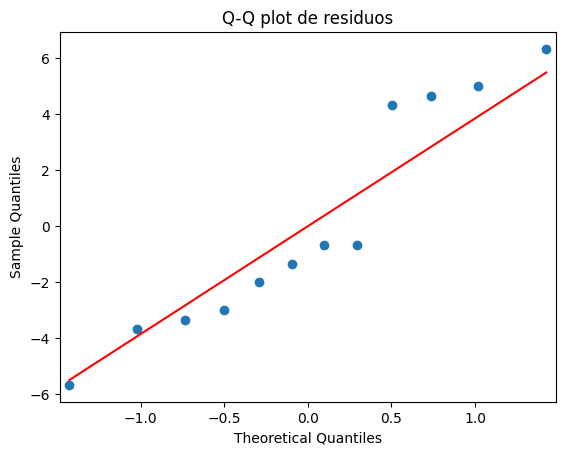

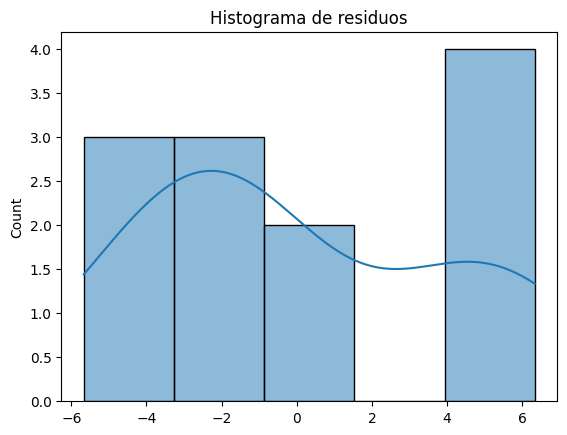

In [ ]:
#Ho: Normalidad
#H1: No hay normalidad

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['detergente'] == 'A']['blancura']
grupo2 = df[df['detergente'] == 'B']['blancura']
grupo3 = df[df['detergente'] == 'C']['blancura']
grupo4 = df[df['detergente'] == 'D']['blancura']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.9432760038375858


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(detergente)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.429


Con respecto al problema anterior:

a) Conteste los tres incisos del problema anterior sin tomar en cuenta el efecto de las lavadoras y obtenga conclusiones.

a) Señale el nombre del diseño experimental utilizado.

Al no tomar en cuenta las lavadoras el diseño deja de ser un diseño en bloques completos al azar y se convierte en un diseño completamente al azar (DCA) con un solo factor que es el tipo de detergente.

b) Formule la hipótesis que se quiere probar en este problema.

H0: Todos los detergentes tienen rendimientos iguales.

H1: Al menos un detergente tiene un rendimiento distinto

c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.

Conforme el valor-p obtenido en el ANOVA que es igual a 0.19229 se puede concluir que no hay diferencia significativa dado que no se rechaza la hipóetsis nula la cual nos indica que todos los detergentes tienen rendimientos iguales y esto se da al ignorar las lavadoras ya que estas si influyen en el resultado de blancura y al no tomarlas en cuenta parece que no hay diferencias en estos detergentes; en el que conforme a los estadísticos de levene y shapiro es posible deducir que los supuestos de normalidad y homoscedasticidad se cumplen por lo que el ANOVA es válido y aunque el tamaño de efecto es moderado a alto siendo que el 42.9% de la variabilidad de la blancura se puede explicar por la varibilidad del detergente, esto nos indica que el detergente podría influir en cierta medida pero esta variabilidad no es estadísticamente suficiente debido a que la variabilidad entre lavadoras queda mezclada y esto hace que se oculte el efecto real de los detergentes; por lo tanto, no se puede afirmar que algún detergente sea mejor que otro bajo este análisis.

b) ¿Hay diferencias en las conclusiones anteriores y las del problema anterior? Explique su respuesta.

Si, si hay diferencias ya que en la anterior el anova nos arrojaba que si hay diferencias estadísticas entre los detergentes mismo que nos inidca que al menos un detergente tiene un rendimiento distintos pero al realizar este analisis el anova nos muestra que no hay diferencia significativa y esto se debe a que no se anulo la varibilidad entre las lavadoras provocando una mezcla con las variaciones que no se pueden explicar lo que hace que el residual que obtuvimos en el anova de este análisis es posible observar que los residuales aumental en gran cantidad a comparación de los anteriores y al aumentar dichos residuales disminuye el potencial del ANOVA evitando que se detecten diferencias que sí aparecen aunque débilemente cuando el bloque esta incluido, por lo que al eliminar el bloque de lavadoras se perdió cierta precisión.


c) ¿Con cuáles conclusiones se queda? Explique su respuesta.

Con las conclusiones obtenidas en el diseño experimental DBCA ya que los detergentes ya que este diseño sí incluye el factor de lavadoras y al incluirlas como bloques nos pemitió anular la varibilidad del error aumentando así la precesión del experimento ya que al momenro que realizamos el análisis sin bloques se distorciono un poco la realidad ya que se igboro en este caso un factor que si afecta o influye en ka blancura por lo que este diseño nos permite obtener conclusiones mpas confiables mientras que el DCA no ya que en este análisis se ignora un factor claro de variabilidad y por esa razón nos lleva a conclusiones que son erróneas.

## Problema 5
Una de las variables críticas en el proceso de ensamble del brazo lector de un disco duro es el ángulo que este forma con el cuerpo principal de la cabeza lectora. Se corre un experimento con el objetivo de comparar dos equipos que miden dicho ángulo en unidades de radianes. Se decide utilizar como factor de bloque a los operadores de los equipos. Los resultados se muestran en la siguiente tabla:

| Operador | Equipo 1                                         | Equipo 2                                         |
|----------|--------------------------------------------------|--------------------------------------------------|
| 1        | 1.328, 0.985, 1.316, 1.553, 1.310               | 1.273, 0.985, 1.134, 1.412, 0.917               |
|          | 1.113, 1.057, 1.144, 1.485, 1.386               | 0.789, 0.671, 0.554, 1.386, 1.289               |
| 2        | 1.269, 1.268, 1.091, 1.195, 1.380               | 1.036, 0.783, 1.108, 1.129, 1.132               |
|          | 1.093, 0.984, 1.087, 1.482, 1.442               | 0.201, 0.900, 0.916, 1.434, 1.223               |
| 3        | 1.440, 1.079, 1.389, 1.611, 1.445               | 1.454, 1.063, 1.219, 1.602, 1.583               |
|          | 1.150, 1.190, 1.247, 1.617, 1.574               | 1.018, 1.050, 0.997, 1.538, 1.478               |

### Preguntas y ejercicios:
a) Plantee el modelo y las hipótesis más adecuadas al problema.  
b) ¿Existen diferencias entre los equipos? Argumente estadísticamente.  
c) ¿Existen diferencias entre los operadores?  
d) Dibuje los diagramas de cajas simultáneos y las gráficas de medias para ambos factores, después interprételas.  
e) Verifique los supuestos de normalidad e igualdad de varianza entre tratamientos, así como la posible presencia de puntos aberrantes.


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
operador,equipo,angulo
1,Equipo1,1.328
1,Equipo1,0.985
1,Equipo1,1.316
1,Equipo1,1.553
1,Equipo1,1.310
1,Equipo2,1.273
1,Equipo2,0.985
1,Equipo2,1.134
1,Equipo2,1.412
1,Equipo2,0.917
1,Equipo1,1.113
1,Equipo1,1.057
1,Equipo1,1.144
1,Equipo1,1.485
1,Equipo1,1.386
1,Equipo2,0.789
1,Equipo2,0.671
1,Equipo2,0.554
1,Equipo2,1.386
1,Equipo2,1.289
2,Equipo1,1.269
2,Equipo1,1.268
2,Equipo1,1.091
2,Equipo1,1.195
2,Equipo1,1.380
2,Equipo2,1.036
2,Equipo2,0.783
2,Equipo2,1.108
2,Equipo2,1.129
2,Equipo2,1.132
2,Equipo1,1.093
2,Equipo1,0.984
2,Equipo1,1.087
2,Equipo1,1.482
2,Equipo1,1.442
2,Equipo2,0.201
2,Equipo2,0.900
2,Equipo2,0.916
2,Equipo2,1.434
2,Equipo2,1.223
3,Equipo1,1.440
3,Equipo1,1.079
3,Equipo1,1.389
3,Equipo1,1.611
3,Equipo1,1.445
3,Equipo2,1.454
3,Equipo2,1.063
3,Equipo2,1.219
3,Equipo2,1.602
3,Equipo2,1.583
3,Equipo1,1.150
3,Equipo1,1.190
3,Equipo1,1.247
3,Equipo1,1.617
3,Equipo1,1.574
3,Equipo2,1.018
3,Equipo2,1.050
3,Equipo2,0.997
3,Equipo2,1.538
3,Equipo2,1.478
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,operador,equipo,angulo
0,1,Equipo1,1.328
1,1,Equipo1,0.985
2,1,Equipo1,1.316
3,1,Equipo1,1.553
4,1,Equipo1,1.310
5,1,Equipo2,1.273
6,1,Equipo2,0.985
7,1,Equipo2,1.134
8,1,Equipo2,1.412
9,1,Equipo2,0.917


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los operadores miden dicho ángulo en unidades radianes iguales.
# H1: Al menos un operador mide dicho ángulo en unidades radianes diferente.

# H0: Todos los equipos miden dicho ángulo en unidades radianes iguales
# H1: Al menos un equipo mide dicho ángulo en unidades radianes diferente


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'angulo ~ C(operador) + C(equipo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(operador),0.588721,2.0,4.834997,0.011561
C(equipo),0.492502,1.0,8.089543,0.006205
Residual,3.409351,56.0,NaN,NaN


valor-p (Shapiro) = 0.055016478051682846


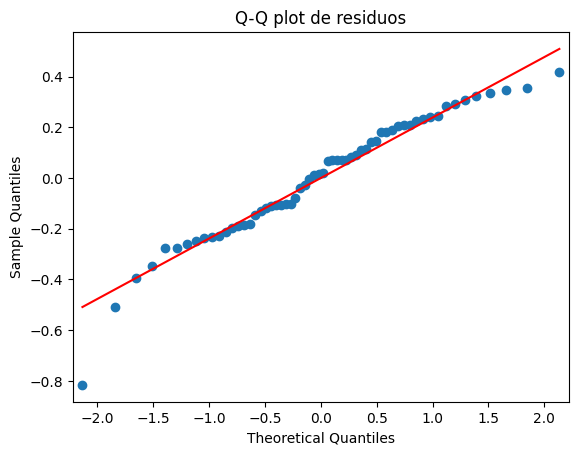

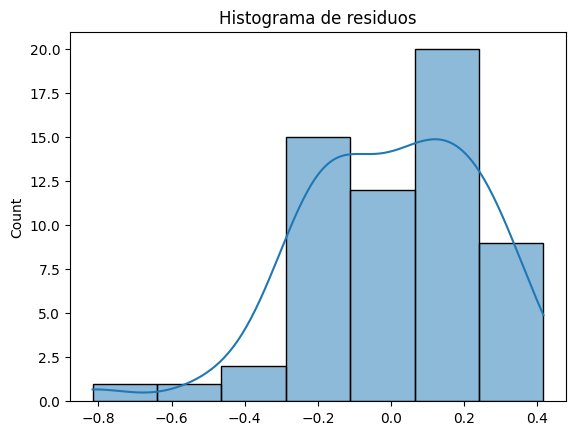

In [ ]:
#Ho: Normalidad
#H1: No hay normalidad

from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['equipo'] == 'Equipo1']['angulo']
grupo2 = df[df['equipo'] == 'Equipo2']['angulo']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.04685739874241189


Lambda óptimo: 1.8779222848260797


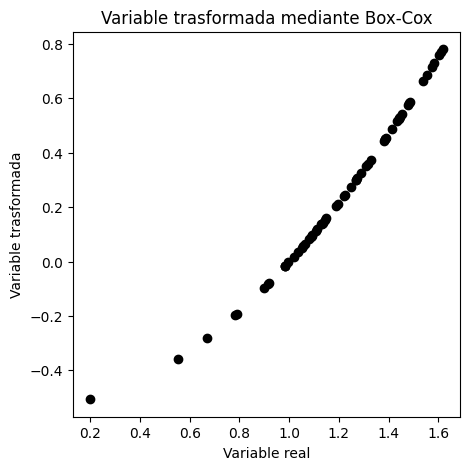

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["angulo_boxcox"], lambda_opt = boxcox(df["angulo"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["angulo"], df["angulo_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
df

,operador,equipo,angulo,angulo_boxcox
0,1,Equipo1,1.328,0.374646
1,1,Equipo1,0.985,-0.014901
2,1,Equipo1,1.316,0.359313
3,1,Equipo1,1.553,0.684600
4,1,Equipo1,1.310,0.351693
5,1,Equipo2,1.273,0.305377
6,1,Equipo2,0.985,-0.014901
7,1,Equipo2,1.134,0.141841
8,1,Equipo2,1.412,0.485385
9,1,Equipo2,0.917,-0.079966


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los operadores miden dicho ángulo en unidades radianes iguales.
# H1: Al menos un operador mide dicho ángulo en unidades radianes diferente.

# H0: Todos los equipos miden dicho ángulo en unidades radianes iguales
# H1: Al menos un equipo mide dicho ángulo en unidades radianes diferente


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'angulo_boxcox ~ C(operador) + C(equipo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(operador),0.764988,2.0,5.407025,0.007128
C(equipo),0.507174,1.0,7.169540,0.009712
Residual,3.961450,56.0,NaN,NaN


valor-p (Shapiro) = 0.1401259378491922


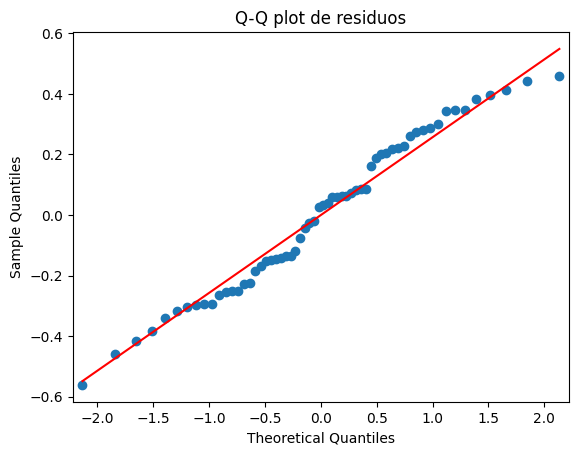

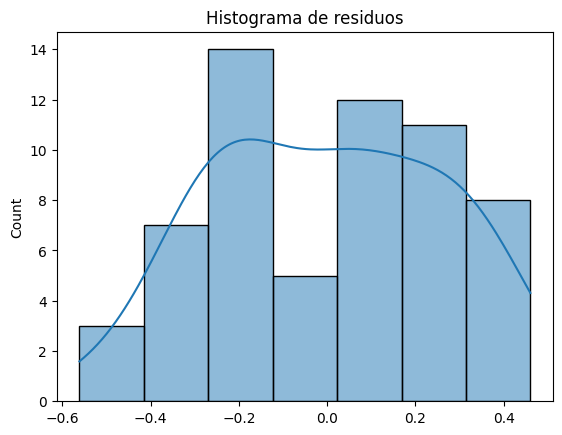

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['equipo'] == 'Equipo1']['angulo_boxcox']
grupo2 = df[df['equipo'] == 'Equipo2']['angulo_boxcox']

stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.17035730871570146


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Equipo1 Equipo2  -0.1839 0.0155 -0.3314 -0.0363   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

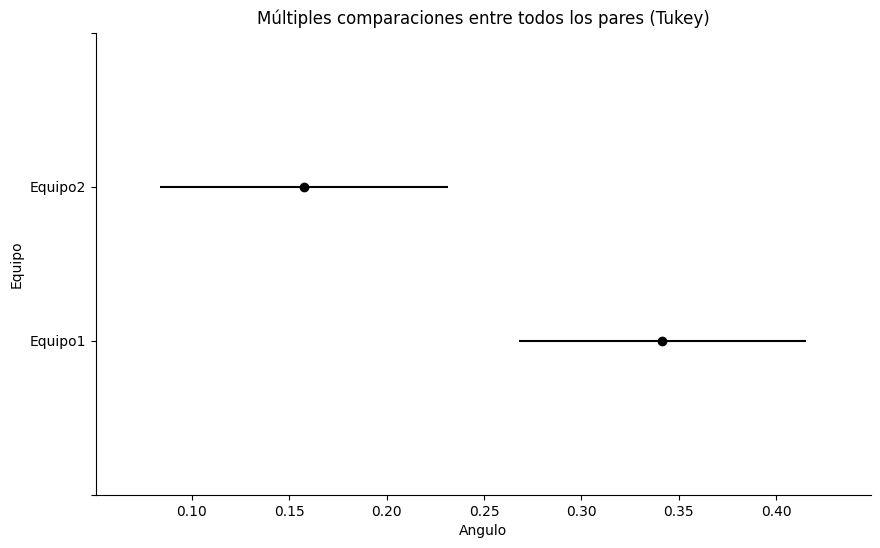

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['angulo_boxcox'], groups=df['equipo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Equipo", xlabel="Angulo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2  -0.0486 0.8474 -0.2617 0.1645  False
     1      3   0.2115 0.0521 -0.0016 0.4246  False
     2      3   0.2601  0.013   0.047 0.4732   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

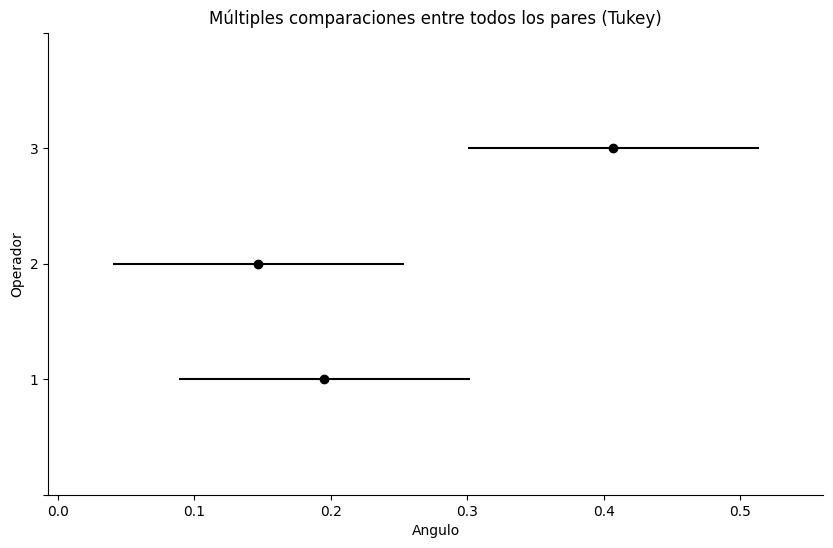

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['angulo_boxcox'], groups=df['operador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Operador", xlabel="Angulo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(equipo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.097


**Preguntas y ejercicios:**

a) Plantee el modelo y las hipótesis más adecuadas al problema.

El modelo usado es el ANOVA y la prueba de boxcox.

 H0: Todos los operadores miden dicho ángulo en unidades radianes iguales.

 H1: Al menos un operador mide dicho ángulo en unidades radianes diferente.

H0: Todos los equipos miden dicho ángulo en unidades radianes iguales

H1: Al menos un equipo mide dicho ángulo en unidades radianes diferente


b) ¿Existen diferencias entre los equipos? Argumente estadísticamente.

Si, si hay diferencias significativas ya que el valor-p obtenido es menor al nivel de significancia de 0.05 en ambas ANOVA que fueron aplicadas por lo que se rechaza la hipótesis nula y se acepta la alternativa que nos inidca que al menos un equipo mide dicho ángulo en unidades radianes diferente, lo cual de la misma manera se pueden observar estás diferencias en la prueba de tuckey realizada en el que en la prueba de tuckey se puede observar que equipo es diferente el cual es el 1 en el que este tiende a medir ángulos más grandes.


c) ¿Existen diferencias entre los operadores?

Si, Si hay diferencias entre los operadores debido a que el valor-p obtenido en ambas ANOVA realizadas anteriormente nos indica que si hay diferencias entre estos ya que este es menor al nivel de significancia de 0.05 lo que nos indica que se acepta la hipótesis alternativa la cual significa que al menos un operador mide dicho ángulo en unidades radianes diferente en el que en la prueba de tuchey se puede observar una diferencia entre los grupos de operadores 2 y 3 en el que el 3 tiende a medir un ángulo mayor que el 2}.

d) Dibuje los diagramas de cajas simultáneos y las gráficas de medias para ambos factores, después interprételas.

Las gráficas obtenidas en la prueba Tuckey nos muestran que tanto el tipo de equipo como algunos operadores generan diferencias en las mediciones del ángulo, por lo que esto nos sugiere que podría ser necesario revisar la calibración de los equipos o estandarizar la forma de medir para evitar variaciones ya que el equipo 1 muestra valores de ángulo más altos que el equipo 2, lo que indica que sí existe una diferencia significativa entre ellos; por lo tanto los dos equipos no miden igual siendo el mismo caso para los operadores en el que el operador 3 obtiene mediciones más altas y el operador 2 las más bajas, mientras que el Operador 1 queda en medio donde solo hay diferencia significativa entre el Operador 2 y el 3 lo que quiere decir que la forma en que cada operador mide sí influye en el resultado.

e) Verifique los supuestos de normalidad e igualdad de varianza entre tratamientos, así como la posible presencia de puntos aberrantes.

Conforme al análisis planteado al principio es posible deducir que no se cumple el supuesto de homoscedasticidad por lo que fue necesario realizar una transformación de Box-Cox con el fin de estabilizar la varianza por lo que ambos supuestos de normalidad y homoscedasticidas se cumplen y esto significa que el modelo ANOVA  es confiable incluyenco cada una de las conclusiones en el que además el valor eta obtenido nos indica que el 9.7% de la variabilidad en en el ángulo se puede explicar por la variabilidad en el equipo y el modelo lo que significa que el efecto de estos es moderado mientras que el 90.3% se debe a otros factores.

## Problema 6
Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. De manera tradicional se han usado termómetros de mercurio (Mer) para verificar que la temperatura sea la adecuada, pero ahora se han comprado termómetros electrónicos (Rtd) para facilitar el proceso de medición. Sin embargo, se duda de las mediciones de estos nuevos dispositivos. Para aclarar dudas y diagnosticar la situación, durante cinco días se toman mediciones con ambos tipos de termómetros en varios silos (a la misma hora). Los datos para cinco silos se muestran a continuación:

| Silo | Día 1 (Mer) | Día 1 (Rtd) | Día 2 (Mer) | Día 2 (Rtd) | Día 3 (Mer) | Día 3 (Rtd) | Día 4 (Mer) | Día 4 (Rtd) | Día 5 (Mer) | Día 5 (Rtd) |
|------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|--|
| A    | 4.0         | 2.6         | 4.0         | 2.8         | 5.0         | 5.0         | 0.5         | 0.0         | 3.0         | 2.4         |
| B    | 5.0         | 6.4         | 6.0         | 6.4         | 2.0         | 2.3         | 4.0         | 4.2         | 4.0         | 4.0         |
| C    | 4.5         | 3.3         | 4.0         | 1.4         | 3.5         | 1.8         | 2.0         | -1.9        | 3.0         | -7.6        |
| D    | 2.5         | 3.1         | 4.0         | 5.0         | 6.5         | 6.6         | 4.5         | 2.7         | 4.0         | 4.0         |
| E    | 4.0         | 0.0         | 4.0         | 3.5         | 0.6         | 2.0         | -4.0        | -4.0        | -4.0        | -6.3        |

**Preguntas:**<br>
a) Observe los datos y establezca una conjetura acerca de la confiabilidad de las mediciones con Rtd (del termómetro de mercurio no hay duda).  
b) Es claro que el silo se puede ver como tratamiento y día como bloque. Considere sólo los datos de Rtd y establezca el modelo estadístico. También haga el ANOVA correspondiente y obtenga conclusiones.  
c) Repita el inciso anterior pero ahora para las mediciones Mer.  
d) ¿Las conclusiones obtenidas en los incisos anteriores coinciden? Comente su respuesta.  
e) Datos pareados. Para comparar los dos métodos de medición (Mer y Rtd) obtenga como variable de respuesta la diferencia de temperatura que registran los métodos para cada día en cada silo. Considerando esto, establezca el modelo estadístico, haga el ANOVA correspondiente y obtenga conclusiones.


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
silo,termometro,dia,temperatura
A,Mer,d1,4.0
A,Rtd,d1,2.6
A,Mer,d2,4.0
A,Rtd,d2,2.8
A,Mer,d3,5.0
A,Rtd,d3,5.0
A,Mer,d4,0.5
A,Rtd,d4,0.0
A,Mer,d5,3.0
A,Rtd,d5,2.4
B,Mer,d1,5.0
B,Rtd,d1,6.4
B,Mer,d2,6.0
B,Rtd,d2,6.4
B,Mer,d3,2.0
B,Rtd,d3,2.3
B,Mer,d4,4.0
B,Rtd,d4,4.2
B,Mer,d5,4.0
B,Rtd,d5,4.0
C,Mer,d1,4.5
C,Rtd,d1,3.3
C,Mer,d2,4.0
C,Rtd,d2,1.4
C,Mer,d3,3.5
C,Rtd,d3,1.8
C,Mer,d4,2.0
C,Rtd,d4,-1.9
C,Mer,d5,3.0
C,Rtd,d5,-7.6
D,Mer,d1,2.5
D,Rtd,d1,3.1
D,Mer,d2,4.0
D,Rtd,d2,5.0
D,Mer,d3,6.5
D,Rtd,d3,6.6
D,Mer,d4,4.5
D,Rtd,d4,2.7
D,Mer,d5,4.0
D,Rtd,d5,4.0
E,Mer,d1,4.0
E,Rtd,d1,0.0
E,Mer,d2,4.0
E,Rtd,d2,3.5
E,Mer,d3,0.6
E,Rtd,d3,2.0
E,Mer,d4,-4.0
E,Rtd,d4,-4.0
E,Mer,d5,-4.0
E,Rtd,d5,-6.3

'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,silo,termometro,dia,temperatura
0,A,Mer,d1,4.0
1,A,Rtd,d1,2.6
2,A,Mer,d2,4.0
3,A,Rtd,d2,2.8
4,A,Mer,d3,5.0
5,A,Rtd,d3,5.0
6,A,Mer,d4,0.5
7,A,Rtd,d4,0.0
8,A,Mer,d5,3.0
9,A,Rtd,d5,2.4


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todos los silos tienen la misma temperatura.
# H1: Al menos un silo tiene una temperatura distinta.

# H0: Todos los días tienen tienen la misma temperatura.
# H1: Al menos un dia tiene temperatura distinta.

# H0: Los termometros registran la misma temperatura
# H1: Al menos un termometro funciona distinto.



# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'temperatura ~ C(silo) + C(termometro) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado


,sum_sq,df,F,PR(>F)
C(silo),168.4692,4.0,8.660872,0.000039
C(termometro),14.4722,1.0,2.976019,0.092227
C(dia),110.4372,4.0,5.677491,0.001025
Residual,194.5176,40.0,NaN,NaN


valor-p (Shapiro) = 0.016256282483184132


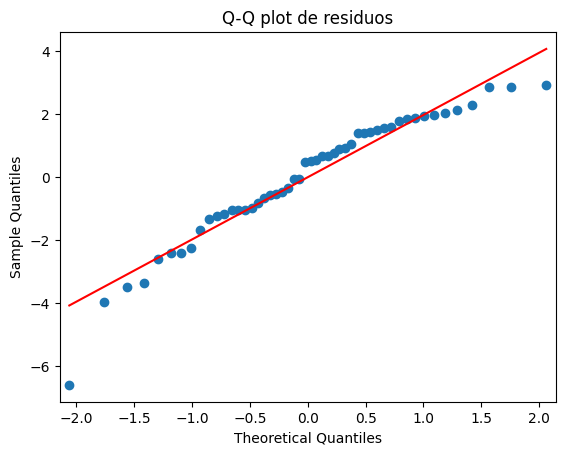

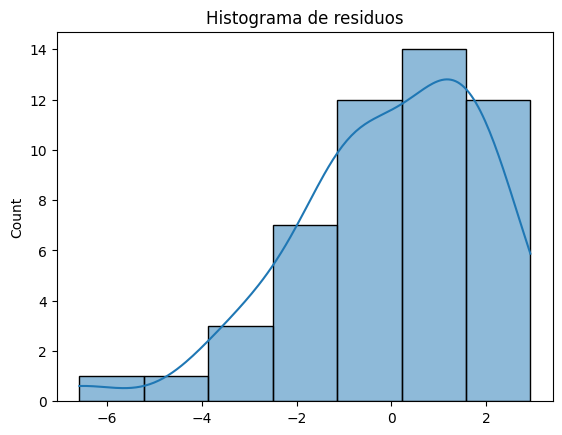

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['termometro'] == 'Mer']['temperatura']
grupo2 = df[df['termometro'] == 'Rtd']['temperatura']


stat, p = levene(grupo1, grupo2)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.1935998956836298


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B      1.5 0.7171 -1.8856  4.8856  False
     A      C    -1.53 0.7021 -4.9156  1.8556  False
     A      D     1.36 0.7838 -2.0256  4.7456  False
     A      E    -3.35 0.0537 -6.7356  0.0356  False
     B      C    -3.03 0.0991 -6.4156  0.3556  False
     B      D    -0.14    1.0 -3.5256  3.2456  False
     B      E    -4.85 0.0017 -8.2356 -1.4644   True
     C      D     2.89 0.1272 -0.4956  6.2756  False
     C      E    -1.82 0.5505 -5.2056  1.5656  False
     D      E    -4.71 0.0024 -8.0956 -1.3244   True
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

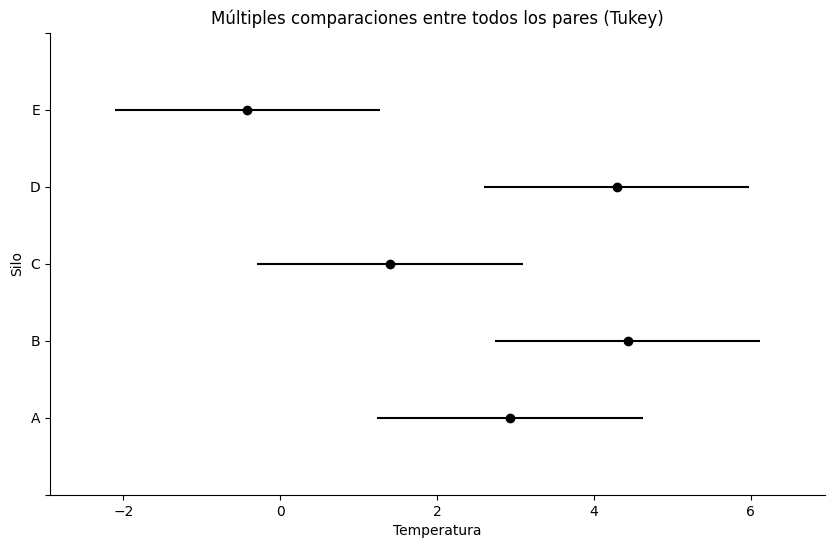

In [ ]:
#PARA APLICAR ESTA ES NECESARIO QUE SE CUMPLA EL ESTADISTICO DE SHAPIRO Y EL TEST DE LEVENE
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['temperatura'], groups=df['silo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Silo", xlabel="Temperatura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    d1     d2     0.57 0.9919 -3.1103 4.2503  False
    d1     d3    -0.01    1.0 -3.6903 3.6703  False
    d1     d4    -2.74 0.2315 -6.4203 0.9403  False
    d1     d5    -2.89  0.187 -6.5703 0.7903  False
    d2     d3    -0.58 0.9914 -4.2603 3.1003  False
    d2     d4    -3.31 0.0964 -6.9903 0.3703  False
    d2     d5    -3.46 0.0745 -7.1403 0.2203  False
    d3     d4    -2.73 0.2347 -6.4103 0.9503  False
    d3     d5    -2.88 0.1898 -6.5603 0.8003  False
    d4     d5    -0.15    1.0 -3.8303 3.5303  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

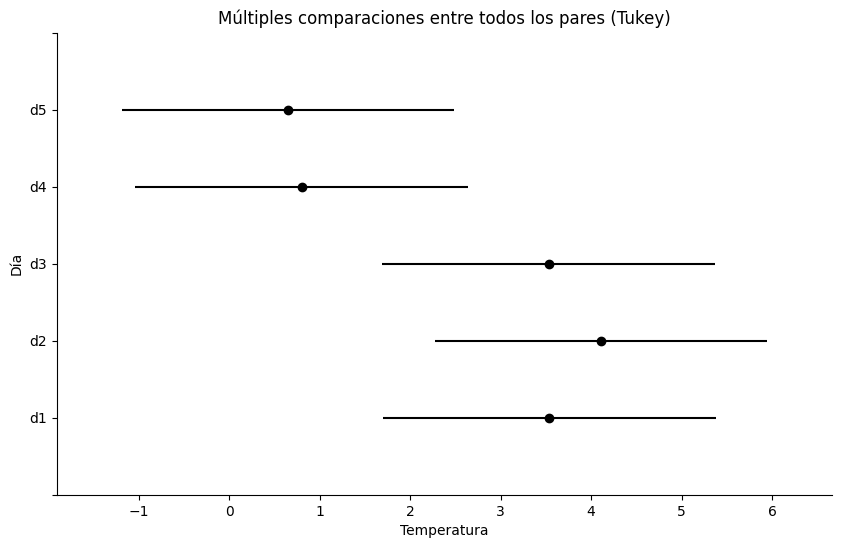

In [ ]:
#PARA APLICAR ESTA ES NECESARIO QUE SE CUMPLA EL ESTADISTICO DE SHAPIRO Y EL TEST DE LEVENE
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['temperatura'], groups=df['dia'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Día", xlabel="Temperatura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(termometro)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.030


RTD

In [ ]:
import pandas as pd
from io import StringIO

data = '''
Silo,Dia,Termometro,Temperatura
A,1, Rtd, 2.6
A,2, Rtd, 2.8
A,3, Rtd, 5.0
A,5, Rtd, 2.4
B,1, Rtd, 6.4
B,2, Rtd, 6.4
B,3, Rtd, 2.3
B,4, Rtd, 4.2
B,5, Rtd, 4.0
C,1, Rtd, 3.3
C,2, Rtd, 1.4
C,3, Rtd, 1.8
C,4, Rtd, 1.9
C,5, Rtd, -7.6
D,2, Rtd, 3.0
D,2, Rtd, 5.0
D,3, Rtd, 6.0
D,4, Rtd, 2.7
F,3, Rtd, 4.0
F,1, Rtd, 0.0
F,2, Rtd, 3.5
F,3, Rtd, 2.0
F,4, Rtd, 4.0
F,5, Rtd, -6.3
'''

df = pd.read_csv(StringIO(data))
df
#Itzel Gabriela Roque Delgado

,Silo,Dia,Termometro,Temperatura
0,A,1,Rtd,2.6
1,A,2,Rtd,2.8
2,A,3,Rtd,5.0
3,A,5,Rtd,2.4
4,B,1,Rtd,6.4
5,B,2,Rtd,6.4
6,B,3,Rtd,2.3
7,B,4,Rtd,4.2
8,B,5,Rtd,4.0
9,C,1,Rtd,3.3


In [ ]:
#ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías (sin incluir 'C(termometro)' ya que solo hay un tipo de termómetro en este df)
modelo_lineal = ols(f'Temperatura ~ C(Silo) + C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(Silo),68.130587,4.0,2.767404,0.066272
C(Dia),88.550421,4.0,3.596839,0.030128
Residual,92.321079,15.0,NaN,NaN


MER

In [ ]:
import pandas as pd
from io import StringIO

data = '''
Silo,Dia,Termometro,Temperatura
A,1, Mer, 4.0
A,2, Mer, 4.0
A,3, Mer, 5.0
A,4, Mer, 6.0
A,5, Mer, 6.0
B,1, Mer, 5.0
B,2, Mer, 6.4
B,3, Mer, 2.0
B,4, Mer, 4.0
B,5, Mer, 4.0
C,1, Mer, 4.5
C,2, Mer, 4.0
C,3, Mer, 3.5
C,4, Mer, 2.0
C,5, Mer, 3.0
D,1, Mer, 2.5
D,2, Mer, 4.0
D,3, Mer, 6.5
D,4, Mer, 4.5
D,5, Mer, 4.0
F,1, Mer, 4.0
F,2, Mer, 4.0
F,3, Mer, 6.0
F,4, Mer, -4.0
F,5, Mer, -4.0

'''

df = pd.read_csv(StringIO(data))
df
#Itzel Gabriela Roque Delgado

,Silo,Dia,Termometro,Temperatura
0,A,1,Mer,4.0
1,A,2,Mer,4.0
2,A,3,Mer,5.0
3,A,4,Mer,6.0
4,A,5,Mer,6.0
5,B,1,Mer,5.0
6,B,2,Mer,6.4
7,B,3,Mer,2.0
8,B,4,Mer,4.0
9,B,5,Mer,4.0


In [ ]:
#ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías (sin incluir 'C(termometro)' ya que solo hay un tipo de termómetro en este df)
modelo_lineal = ols(f'Temperatura ~ C(Silo) + C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(Silo),43.5296,4.0,1.768087,0.184640
C(Dia),20.6896,4.0,0.840371,0.519583
Residual,98.4784,16.0,NaN,NaN


Preguntas:

a) Observe los datos y establezca una conjetura acerca de la confiabilidad de las mediciones con Rtd (del termómetro de mercurio no hay duda).

Al observar los datos se nota que en varios días el termómetro Rtd registra valores considerablemente más bajos que el termómetro de mercurio en el que algunos silos aparecen valores negativos que no coinciden con las mediciones Mer; esto sugiere que el Rtd podría presentar errores sistemáticos o mayor variabilidad, por lo que su confiabilidad es cuestionable.

b) Es claro que el silo se puede ver como tratamiento y día como bloque. Considere sólo los datos de Rtd y establezca el modelo estadístico. También haga el ANOVA correspondiente y obtenga conclusiones.

H0: Todos los silos tienen la misma temperatura con el termometro RTD.
H1: Al menos un silo tiene una temperatura distinta con el termometro RTD.

H0: Todos los días tienen tienen la misma temperatura con el termometro Rtd.
H1: Al menos un dia tiene temperatura distinta con el termometro Rtd.

H0: Los termometros registran la misma temperatura con el termometro Rtd
H1: Al menos un termometro funciona distinto con el termometro Rtd.

Para las mediciones con Rtd, el modelo estadístico es un diseño en bloques completos al azar con silo como tratamiento y día como bloque en el que el ANOVA nos muestra que no hay diferencias significativas entre silos ya que el valor-p es de 0.066272, pero sí entre días ya que el valor-p es de 0.030128, lo que nos indica que el factor día influye de manera significativa en las lecturas del termómetro electrónico, mientras que las variaciones entre silos no son concluyentes.

c) Repita el inciso anterior pero ahora para las mediciones Mer.

Para las mediciones con Mer, se aplicó el mismo modelo pero en este caso el ANOVA nos arrojó que ni los silos que tienen un valor-p = 0.184640 ni los días con un valor-p = 0.519583 presentan diferencias significativas, por lo que las lecturas del termómetro de mercurio se mantienen estables sin depender de estos factores.

d) ¿Las conclusiones obtenidas en los incisos anteriores coinciden? Comente su respuesta.

Las conclusiones coinciden en que no hay diferencias significativas entre silos, pero difieren en el efecto del día: Rtd sí muestra variación temporal, mientras que Mer no. Esto sugiere que el termómetro electrónico es más sensible o menos confiable frente a cambios en el tiempo, lo que podría deberse a factores ambientales o de calibración.

e) Datos pareados. Para comparar los dos métodos de medición (Mer y Rtd) obtenga como variable de respuesta la diferencia de temperatura que registran los métodos para cada día en cada silo. Considerando esto, establezca el modelo estadístico, haga el ANOVA correspondiente y obtenga conclusiones.

Al analizar las diferencias pareadas Mer−Rtd, el modelo nos indica que tanto el silo como el día tienen efectos significativos sobre las discrepancias, mientras que el sesgo promedio entre termómetros no resulta estadísticamente relevante. El ANOVA nos confirma que el día valor-p = 0.001025 y el silo explican gran parte de la variabilidad, mientras que el factor termómetro no aporta información adicional; en el que la prueba de Levene respalda la homogeneidad de varianzas, y en conjunto se concluye que las variaciones dependen más de condiciones específicas de silo y día que del tipo de termómetro, aunque Rtd muestra mayor inestabilidad.

## Problema 7
Se quiere estudiar el efecto de cinco diferentes catalizadores (**A, B, C, D y E**) sobre el **tiempo de reacción** de un proceso químico. Cada lote de material sólo permite cinco corridas y cada corrida requiere aproximadamente 1.5 horas, por lo que sólo se pueden realizar cinco corridas diarias. El experimentador decide correr los experimentos con un diseño en cuadro latino para controlar activamente a los **lotes y días**. Los datos obtenidos son:

| Lote | Día 1 | Día 2 | Día 3 | Día 4 | Día 5 |
|------|-------|-------|-------|-------|-------|
| 1    | A = 8 | B = 7 | D = 1 | C = 7 | E = 3 |
| 2    | C = 11| E = 2 | A = 7 | D = 3 | B = 8 |
| 3    | B = 4 | A = 9 | C = 10| E = 1 | D = 5 |
| 4    | D = 6 | C = 8 | E = 6 | B = 6 | A = 10|
| 5    | E = 4 | D = 2 | B = 3 | A = 8 | C = 8 |


**Preguntas:**<br>
a) ¿Cómo se aleatorizó el experimento?  
b) Anote la ecuación del modelo y las hipótesis estadísticas correspondientes.  
c) ¿Existen diferencias entre los tratamientos? ¿Cuáles tratamientos son diferentes entre sí?  
d) ¿Los factores de ruido, lote y día afectan el tiempo de reacción del proceso?  
e) Dibuje los gráficos de medias para los tratamientos, los lotes y los días. ¿Cuál tratamiento es mejor?  
f) Verifique los supuestos del modelo, considerando que los datos se obtuvieron columna por columna, día a día.


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
lote,dia,catalizador,tiempo
1,1,A,8
1,2,B,7
1,3,D,1
1,4,C,7
1,5,E,3
2,1,C,11
2,2,E,2
2,3,A,7
2,4,D,3
2,5,B,8
3,1,B,4
3,2,A,9
3,3,C,10
3,4,E,1
3,5,D,5
4,1,D,6
4,2,C,8
4,3,E,6
4,4,B,6
4,5,A,10
5,1,E,4
5,2,D,2
5,3,B,3
5,4,A,8
5,5,C,8
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,lote,dia,catalizador,tiempo
0,1,1,A,8
1,1,2,B,7
2,1,3,D,1
3,1,4,C,7
4,1,5,E,3
5,2,1,C,11
6,2,2,E,2
7,2,3,A,7
8,2,4,D,3
9,2,5,B,8


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# H0: Todos los lotes tienen corridas de tiempo iguales
# H1: Al menos un lote tiene una corrida de tiempo distinta.

# H0: Todos los días tienen tiempos de corrida iguales.
# H1: Al menos un día tiene un tiempo de corrida diferente.

#H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción
#H0: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto


# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(lote) + C(dia) + C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(lote),15.44,4.0,1.234542,0.347618
C(dia),12.24,4.0,0.978678,0.455014
C(catalizador),141.44,4.0,11.309168,0.000488
Residual,37.52,12.0,NaN,NaN


In [ ]:
print(modelo_lineal.params,"\n")

Intercept              8.44
C(lote)[T.2]           1.00
C(lote)[T.3]           0.60
C(lote)[T.4]           2.00
C(lote)[T.5]          -0.20
C(dia)[T.2]           -1.00
C(dia)[T.3]           -1.20
C(dia)[T.4]           -1.60
C(dia)[T.5]            0.20
C(catalizador)[T.B]   -2.80
C(catalizador)[T.C]    0.40
C(catalizador)[T.D]   -5.00
C(catalizador)[T.E]   -5.20
dtype: float64 



valor-p (Shapiro) = 0.5476371878728061


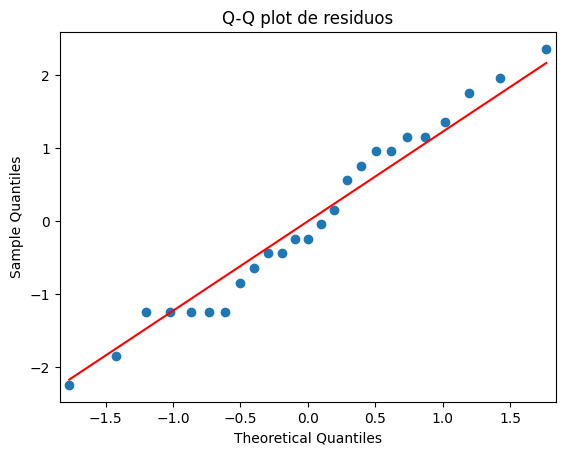

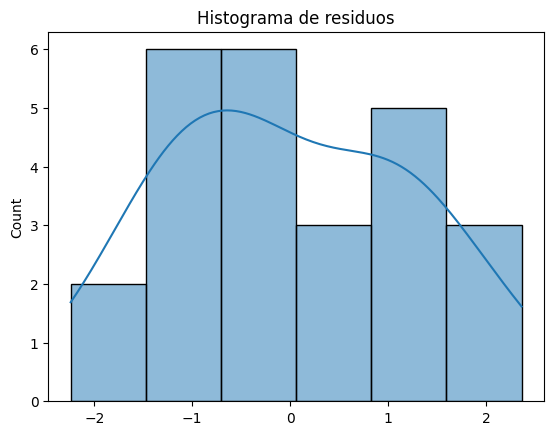

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo']
grupo2 = df[df['catalizador'] == 'B']['tiempo']
grupo3 = df[df['catalizador'] == 'C']['tiempo']
grupo4 = df[df['catalizador'] == 'D']['tiempo']
grupo5 = df[df['catalizador'] == 'E']['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.7751009409046274


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

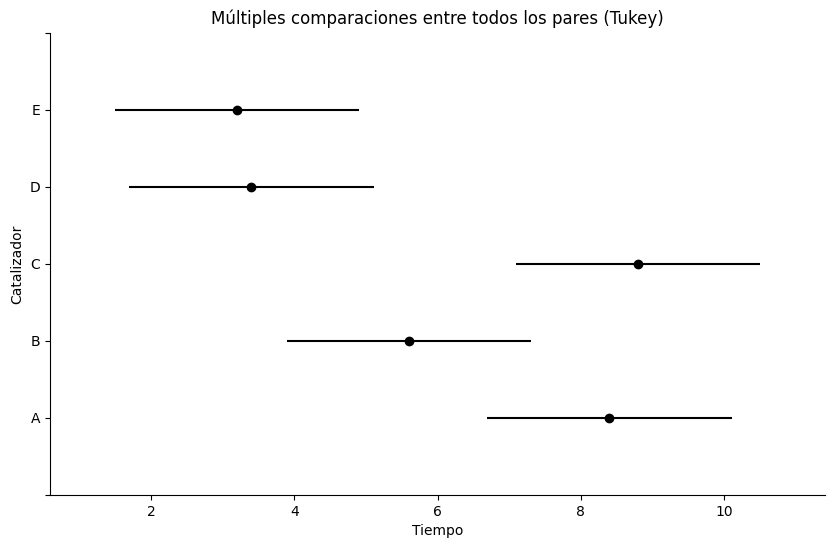

In [ ]:
#PARA APLICAR ESTA ES NECESARIO QUE SE CUMPLA EL ESTADISTICO DE SHAPIRO Y EL TEST DE LEVENE
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Catalizador", xlabel="Tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(catalizador)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.684


Preguntas:

a) ¿Cómo se aleatorizó el experimento?

El experimento se aleatorizó conforme a las columnas y los renglones:

Bloque 1: lote 1, Lote 2,lote 3, lote 4 y lote 5.

Bloque 2: dia 1, dia 2, dia 3, dia 4 y dia 5

Variable de interés: catalizador A, catalizador B, catalizador C, catalizador D y catalizador E.

Variable de comparación (respuesta): tiempo de reacción  

Por lo que conforme a lo anterior, es decir que, el experimento se aleatorizó mediante un diseño en cuadro latino de 5 x 5, asignando cada catalizador exactamente una vez por lote y por día, con ejecución real por columnas.

b) Anote la ecuación del modelo y las hipótesis estadísticas correspondientes.

Tiempo estimado= 8.44+ 1.00 (L2) + 0.60 (L3) + 2.00 (L4) - 0.20 (L5) - 1.00 (D2) - 1.20 (D3) -1.60 (D4) + 0.20(D5) - 2.80 (CB) + 0.40 (CC) - 5.00 (CD) - 5.20 (CE)

H0: Todos los lotes tienen corridas de tiempo iguales.

H1: Al menos un lote tiene una corrida de tiempo distinta.

H0: Todos los días tienen tiempos de corrida iguales.

H1: Al menos un día tiene un tiempo de corrida diferente.

H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción

H1: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto

c) ¿Existen diferencias entre los tratamientos? ¿Cuáles tratamientos son diferentes entre sí?

conforme al valor-p obtenido en el ANOVA este nos inidca que si hay diferencias entre los tratamientos ya que este es menos al nivel de significancia y nos indica que se acepta la hipótesis alternativa que es que al menos un catalizador tienen un efecto sobre el tiempo de reacción distinto en el que conforme a la prueba de tuckey se puede observar que los catalizadores que son diferentes entre sí A y D, A y E, C y D y C y E; en donde el C seguido por el A es el que tiene el mayor efecto sobre el tiempo de reacción lo que quiere decir que tiene reacciones un poco más lentas.

d) ¿Los factores de ruido, lote y día afectan el tiempo de reacción del proceso?

Conforme el valor-p obtenido en el ANOVA para el factor ruído es de 0.347618 nos indica que no hay diferencia significativa y para el factor día es el mismo caso donde el valor-p es de 0.4550 donde no se rechaza la hipótesis nula para ambos factores y esto nos indica que Ni los lotes ni los días afectan el tiempo de reacción, por lo que es posible deducir que el diseño en cuadro latino funcionó correctamente para controlar esos efectos.


e) Dibuje los gráficos de medias para los tratamientos, los lotes y los días.
¿Cuál tratamiento es mejor?

El mejor tratamiento es el catalizador E ya que tiene un menor tiempo promedio y aparece consistentemente con los valores más bajos en donde es significativamente diferente de A, B y C en donde el D también podría ser otra opción si se quiere un tipo de reacción un poquito más lenta; en el que el tratamiento que no es el mejor es el C y seguido el A ya que tienen tiempos más altos. En el que el efecto que tienen los catalizadores es muy grande ya que el 64.8% de la variabilidad en el tiempo se puede explicara por la variabilidad del catalizador y del modelo.

f) Verifique los supuestos del modelo, considerando que los datos se obtuvieron columna por columna, día a día.

Respecto a los estadisticos de shapiro y levene se cumplen los supuestos todos los supuestos de levene ya que en ninguno de los dos se rechazo la hipótesis nula debido a que el valor-p obtenido en ambos es mayor al nivel de significancia de 0.05 por lo que los residuales si son normales y las varianzas son iguales, por lo que los resultados del ANOVA y tuckey son confiables.

## Problema 8
En el problema anterior elimine el factor de bloque días, y conteste:

a) ¿Se justifica la eliminación?  
b) Sin tomar en cuenta el día, señale el nombre del diseño, el modelo y las hipótesis más adecuadas al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error, en este caso con el del problema anterior. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y del anterior?


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
lote,catalizador,tiempo
1,A,8
1,B,7
1,D,1
1,C,7
1,E,3
2,C,11
2,E,2
2,A,7
2,D,3
2,B,8
3,B,4
3,A,9
3,C,10
3,E,1
3,D,5
4,D,6
4,C,8
4,E,6
4,B,6
4,A,10
5,E,4
5,D,2
5,B,3
5,A,8
5,C,8
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,lote,catalizador,tiempo
0,1,A,8
1,1,B,7
2,1,D,1
3,1,C,7
4,1,E,3
5,2,C,11
6,2,E,2
7,2,A,7
8,2,D,3
9,2,B,8


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# H0: Todos los lotes tienen corridas de tiempo iguales
# H1: Al menos un lote tiene una corrida de tiempo distinta.

#H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción
#H0: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto


# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(lote) + C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(lote),15.44,4.0,1.241158,0.333144
C(catalizador),141.44,4.0,11.369775,0.000146
Residual,49.76,16.0,NaN,NaN


valor-p (Shapiro) = 0.04246184389935428


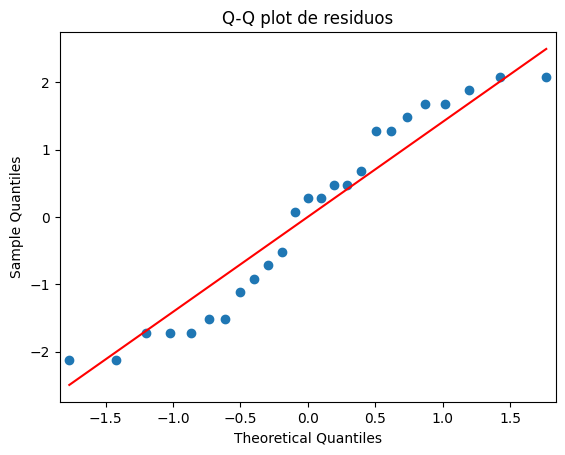

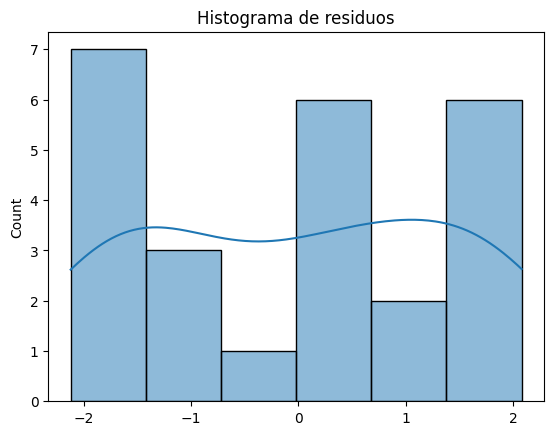

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo']
grupo2 = df[df['catalizador'] == 'B']['tiempo']
grupo3 = df[df['catalizador'] == 'C']['tiempo']
grupo4 = df[df['catalizador'] == 'D']['tiempo']
grupo5 = df[df['catalizador'] == 'E']['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.7751009409046274


Lambda óptimo: 0.8614779727199691


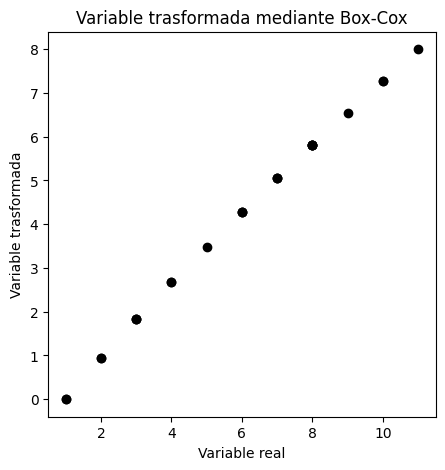

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["tiempo_boxcox"], lambda_opt = boxcox(df["tiempo"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["tiempo"], df["tiempo_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
df

,lote,catalizador,tiempo,tiempo_boxcox
0,1,A,8,5.801428
1,1,B,7,5.044881
2,1,D,1,0.000000
3,1,C,7,5.044881
4,1,E,3,1.829990
5,2,C,11,7.999145
6,2,E,2,0.948253
7,2,A,7,5.044881
8,2,D,3,1.829990
9,2,B,8,5.801428


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Nivel de significancia = 0.05
# H0: Todos los lotes tienen corridas de tiempo iguales
# H1: Al menos un lote tiene una corrida de tiempo distinta.

#H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción
#H0: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'tiempo_boxcox ~ C(lote) + C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(lote),10.054729,4.0,1.228478,0.337925
C(catalizador),89.225448,4.0,10.901488,0.000185
Residual,32.738815,16.0,NaN,NaN


valor-p (Shapiro) = 0.06942314577335465


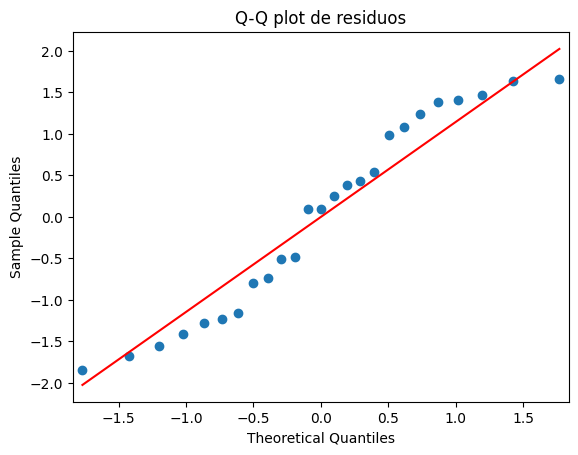

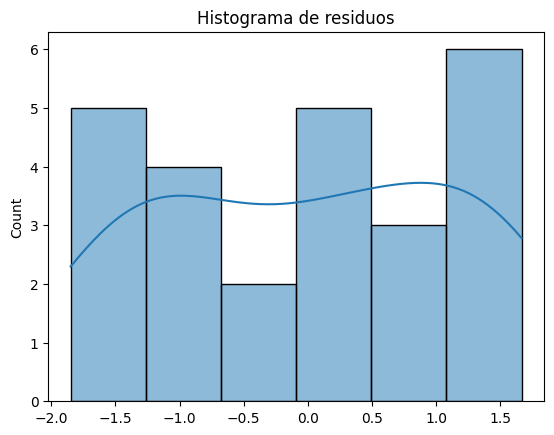

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo_boxcox']
grupo2 = df[df['catalizador'] == 'B']['tiempo_boxcox']
grupo3 = df[df['catalizador'] == 'C']['tiempo_boxcox']
grupo4 = df[df['catalizador'] == 'D']['tiempo_boxcox']
grupo5 = df[df['catalizador'] == 'E']['tiempo_boxcox']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.6436506564139076


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B  -2.1698 0.1719 -4.9382  0.5985  False
     A      C   0.2908 0.9977 -2.4775  3.0592  False
     A      D   -3.987 0.0028 -6.7554 -1.2187   True
     A      E  -4.1494 0.0019 -6.9178 -1.3811   True
     B      C   2.4607 0.0967 -0.3077   5.229  False
     B      D  -1.8172 0.3181 -4.5855  0.9512  False
     B      E  -1.9796 0.2426  -4.748  0.7887  False
     C      D  -4.2779 0.0014 -7.0462 -1.5095   True
     C      E  -4.4403 0.0009 -7.2086 -1.6719   True
     D      E  -0.1624 0.9998 -2.9308  2.6059  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

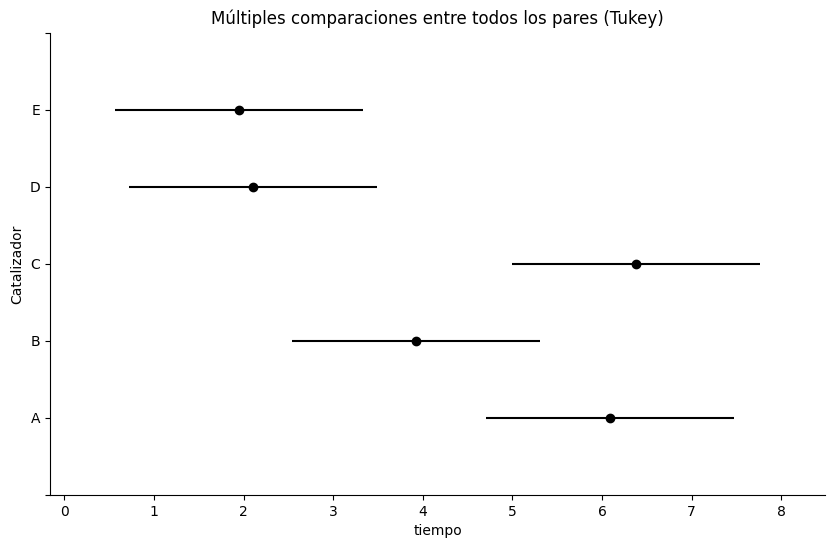

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo_boxcox'], groups=df['catalizador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Catalizador", xlabel="tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(catalizador)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.676


En el problema anterior elimine el factor de bloque días, y conteste:

a) ¿Se justifica la eliminación?

Sí, la eliminación del factor día si se justifica ya que en el problema anterior, el ANOVA nos mostró que el factor día no fue significativo o este mostró que no hay diferencia significativa ya que el valor-p es mayor al nivel de significancia de 0.05 lo que esto significa que los días no influyeron en el tiempo de reacción, por lo que no aportaban información útil al modelo, por eso se puede eliminar sin afectar el análisis de los catalizadores.

b) Sin tomar en cuenta el día, señale el nombre del diseño, el modelo y las hipótesis más adecuadas al problema.

El nombre del diseño es un DCA (Diseño completamente al azar) con 5 tratamientos que son los catalizadores. El modelo estadístico es ANOVA mediante la transformación de boxcox.

H0: Todos los lotes tienen corridas de tiempo iguales
H1: Al menos un lote tiene una corrida de tiempo distinta.

H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción
H1: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto

c) Pruebe las hipótesis y obtenga conclusiones.

La tabla ANOVA nos arrojó un valor-p de 0.000185 para el factor Catalizador, por lo que es decir, hay evidencia estadística suficiente para afirmar que al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto al resto, en el que ara identificar qué grupos son difierentes se aplicó la prueba de Tukey y los resultados nos muestran diferencias significativas entre los grupos: A–D, A–E, C–D y C–E todos con un avlor-p ajustados menor al nivel de significancia de 0.05, mientras que los demás grupos no son significativamente diferentes; en el que los catalizadores D y E producen tiempos significativamente menores que A y C; por lo que E es el que reporta los tiempos más bajos y es el mejor si se busca minimizar el tiempo y C es el que produce los tiempos más altos. Conforme el valor obtenido en el eta que es el tamaño del efecto esta nos inidca que el efecto es grande lo que indica que aproximadamente el 67.6% de la variabilidad en el tiempo de reacción se puede explicar por el tipo de catalizador y el modelo; en el que además, las pruebas de supuestos Shapiro  y Levene no mostraron violaciones importantes, por lo que el ANOVA y Tukey son confiables junto con las conclusiones correspondientes.

d) Compare el cuadro medio del error, en este caso con el del problema anterior. ¿Qué observa? ¿Cómo lo explica?

En relación a la parte del apartado de residual que nos arroja el ANOVA de ambos problemas es posible observar que el cuadro medio del error del primer problema donde se toman en cuenta todos los factores al realizar la operación de 37.52/12 (grados de libertad que marca el ANOVA en la parte de df)= 3.1267 y para el segundo problema donde no se toma en cuenta el factor bloque día la operación es 32.738815/16= 2.0461759375. Conforme a lo anterior al comparar el cuadro medio del error del modelo completo con lotes, días y catalizadores (3.13) con el del modelo donde se eliminó el factor día (2.05), se observa que el error residual disminuye de manera ligera cuando el día no se incluye en el análisis y esto sucede porque el factor día no explicaba variación real en los datos, o es decir que, no había diferencia significativa dado que su p-valor era mayor que 0.05, por lo que al quitarlo la variabilidad que antes se repartía entre ese bloque pasa directamente al residuo sin afectar negativamente el ajuste; en consecuencia, el modelo reducido sigue funcionando bien y las conclusiones sobre los catalizadores no cambian, lo que confirma que el día no aportaba información importante en el experimento.

e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y del anterior?

Las conclusiones sobre los catalizadores salen iguales en los dos análisis porque el día no afecta realmente los tiempos de reacción. Como el día no cambia los resultados, al quitarlo del modelo todo sigue igual y los catalizadores se comportan de la misma manera, es decir, el comportamiento de los catalizadores es consistente independientemente del día en que se realizaron las corridas; por lo que aunque se use el modelo completo o el modelo sin el día, siempre se llegará a la misma conclusión sobre cuáles catalizadores son diferentes.

## Problema 9
Con respecto a los problemas 7 y 8, además de eliminar el factor día ahora elimine el factor lote, y conteste lo siguiente:

a) ¿Se justifica esta segunda eliminación en ambos problemas?  
b) Después de la doble eliminación, señale el nombre del diseño, el modelo y la(s) hipótesis más adecuada(s) al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error obtenido con los de los problemas 16 y 17. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y de los dos anteriores?  
f) ¿Cree que esta eliminación hubiese afectado si los factores de bloque hubieran sido significativos?  


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
catalizador,tiempo
A,8
B,7
D,1
C,7
E,3
C,11
E,2
A,7
D,3
B,8
B,4
A,9
C,10
E,1
D,5
D,6
C,8
E,6
B,6
A,10
E,4
D,2
B,3
A,8
C,8
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,catalizador,tiempo
0,A,8
1,B,7
2,D,1
3,C,7
4,E,3
5,C,11
6,E,2
7,A,7
8,D,3
9,B,8


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd


#H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción
#H1: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto


# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'tiempo ~ C(catalizador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(catalizador),141.44,4.0,10.846626,0.000077
Residual,65.20,20.0,NaN,NaN


valor-p (Shapiro) = 0.29334160847597607


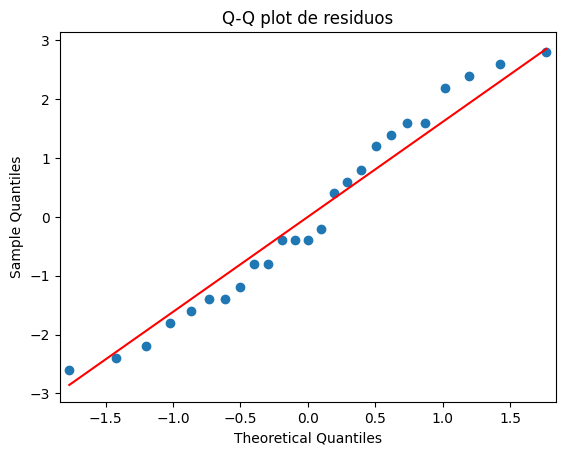

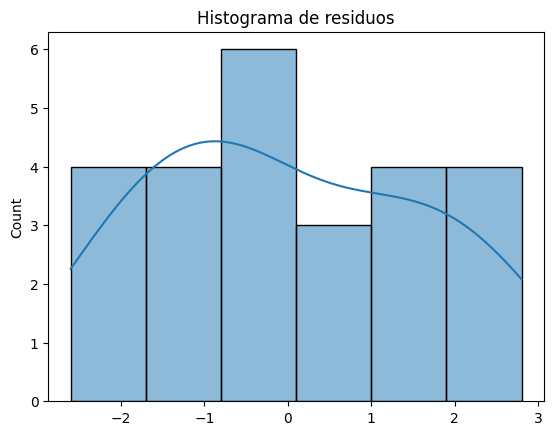

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['catalizador'] == 'A']['tiempo']
grupo2 = df[df['catalizador'] == 'B']['tiempo']
grupo3 = df[df['catalizador'] == 'C']['tiempo']
grupo4 = df[df['catalizador'] == 'D']['tiempo']
grupo5 = df[df['catalizador'] == 'E']['tiempo']


stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.7751009409046274


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

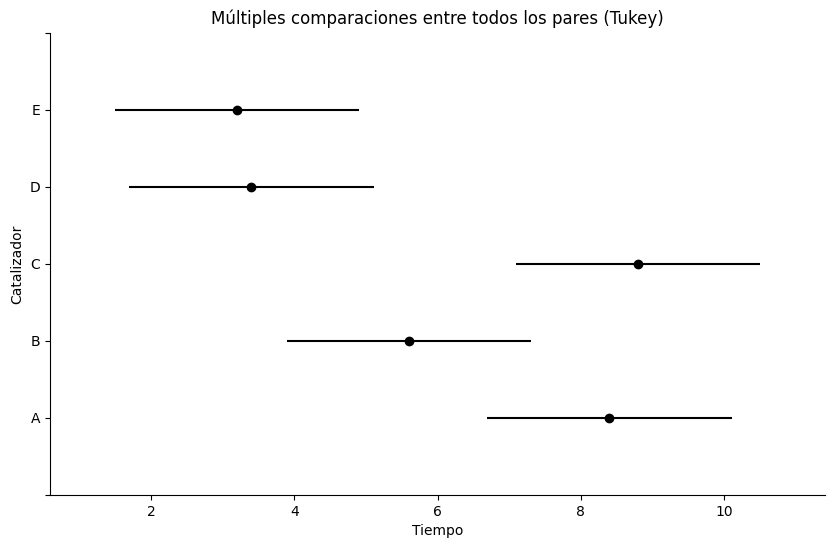

In [ ]:
#PARA APLICAR ESTA ES NECESARIO QUE SE CUMPLA EL ESTADISTICO DE SHAPIRO Y EL TEST DE LEVENE
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['tiempo'], groups=df['catalizador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Catalizador", xlabel="Tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(catalizador)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.684


Con respecto a los problemas 7 y 8, además de eliminar el factor día ahora elimine el factor lote, y conteste lo siguiente:

a) ¿Se justifica esta segunda eliminación en ambos problemas?

Sí se justifica ya que al eliminar primero el factor día y ahora el factor lote, ambos mostraron valores-p mayores a 0.05 en los ANOVA anteriores, lo que nos indica que ninguno de los dos factores tenía un efecto significativo sobre el tiempo de reacción y como no aportan explicación real a la variabilidad se pueden quitar sin afectar las conclusiones sobre los catalizadores.

b) Después de la doble eliminación, señale el nombre del diseño, el modelo y la(s) hipótesis más adecuada(s) al problema.

Ahora se tiene un diseño completamente aleatorizado (DCA), ya que sólo queda un factor que es el catalizador y este es sin bloques en donde el modelo utilizado es ANOVA.

H0: Todos los catalizadores tienen el mismo efecto sobre el tiempo de reacción.

H1: Al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto.

c) Pruebe las hipótesis y obtenga conclusiones.

La tabla ANOVA nos arrojó un valor-p de 0.000077 que es mnor al nivel de significancia de 0.05 por lo que rechazamos la hipótesis nula y concluimos que si hay diferencias significativas entre los catalizadores, lo que significa que al menos un catalizador tiene un efecto sobre el tiempo de reacción distinto en donde la de Tukey nos indica que las diferencias significativas se dan entre los grupos A–D, A–E, C–D y C–E debido a que tienen un valor-p ajustado menor a 0.05, es decir, los catalizadores D y E producen tiempos de reacción significativamente menores que los ctalizadores A y C; en donde el tamaño del efecto es grande en donde el 68.4% se puede explicar por la variabilidad del tiempo de reacción y por la variabilidad del catalizador, lo que confirma que el tipo de catalizador explica una parte importante de la variación en el tiempo; además, las pruebas de supuestos de shapiro y levene no muestran problemas importantes  por lo que el ANOVA y Tukey son confiables junto con sus respectivas conclusiones.

d) Compare el cuadro medio del error obtenido con los de los problemas 16 y 17. ¿Qué observa? ¿Cómo lo explica?

En relación a la parte del apartado de residual que nos arroja el ANOVA de ambos problemas es posible observar que el cuadro medio del error del primer problema donde se toman en cuenta todos los factores al realizar la operación de 37.52/12 (grados de libertad que marca el ANOVA en la parte de df)= 3.1267 y para el segundo problema donde no se toma en cuenta el factor bloque día la operación es 32.738815/16= 2.0461759375 siendo así mismo para el último ANOVA obtenido donde se eliminaron ambos factores respecto a la operación de 65.20/20= 3.26 que es el valor correspondiente al cuadro medio del error. Es posible observa que el cuadro medio vuelve a subir ligeramente al eliminar ambos factores de bloque; lo que significa que los bloques ayudan a controlar variabilidad y aunque lote y día no fueron significativos, si oordenaban parte de esa variación ya que alquitarlos, la variabilidad residual aumentó un poco; pero sin embargo, esto no afecta el resultado principal que es el efecto del catalizador donde este sigue siendo claramente significativo.

e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y de los dos anteriores?

Porque el efecto del catalizador es muy fuerte frente al ruido del experimento; por lo que los factores eliminados (día y lote) no eran significativos, no explicaban la variación importante y no cambiaban el patrón entre los catalizadores. Por eso, incluso al quitarlos la diferencia entre catalizadores se mantiene igual y se llegan a las mismas conclusiones en los tres problemas.

f) ¿Cree que esta eliminación hubiese afectado si los factores de bloque hubieran sido significativos?

Sí, si el día o lote hubieran sido significativos, eliminarlos sería incorrecto porque aumentarían de manera artificial el error, reducirían la precisión del ANOVA y podrían cambiar las conclusiones sobre cuáles catalizadores son diferentes; pero como no fueron significativos el eliminarlos no dañó el análisis realizado.

## Problema 10
Se comprueba el peso en gramos de un material de tres proveedores: **A, B y C**, por tres diferentes inspectores: **I, II y III**, utilizando tres diferentes escalas: **1, 2 y 3**. El experimento se lleva a cabo como el siguiente cuadro latino:

| Inspector | Escala 1 | Escala 2 | Escala 3 |
|-----------|----------|----------|----------|
| I         | A = 16   | B = 10   | C = 11   |
| II        | B = 15   | C = 9    | A = 14   |
| III       | C = 13   | A = 11   | B = 13   |

**Preguntas:**<br>
a) ¿Hay diferencias entre los proveedores?  
b) ¿Hay diferencias entre los inspectores y entre las escalas?  
c) Si el peso debe ser 15 g, ¿cuál proveedor es mejor?  
d) Si algún factor de bloque es no significativo, elimínelo y haga el análisis adecuado.  


In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
inspector,escala,proveedor,peso
1,1,A,16
1,2,B,10
1,3,C,11
2,1,B,15
2,2,C,9
2,3,A,14
3,1,C,13
3,2,A,11
3,3,B,13
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,inspector,escala,proveedor,peso
0,1,1,A,16
1,1,2,B,10
2,1,3,C,11
3,2,1,B,15
4,2,2,C,9
5,2,3,A,14
6,3,1,C,13
7,3,2,A,11
8,3,3,B,13


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd


#H0: Todos los inspectores miden el peso del material de la misma manera.
#H1: Al menos un ispector mide el peso del material de manera diferente.

#H0: Todas las escalas miden el peso del material de la misma manera
#H1: Al menos una escala mide el peso del material de manera distinta

#H0: Todos los proveedores producen materiales con el mismo peso
#H1: Al menos un proveedor produce un material con un peso distinto


# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'peso ~ C(inspector) + C(escala) + C(proveedor)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(inspector),0.222222,2.0,1.0,0.500000
C(escala),32.888889,2.0,148.0,0.006711
C(proveedor),10.888889,2.0,49.0,0.020000
Residual,0.222222,2.0,NaN,NaN


valor-p (Shapiro) = 0.00015259147070220818


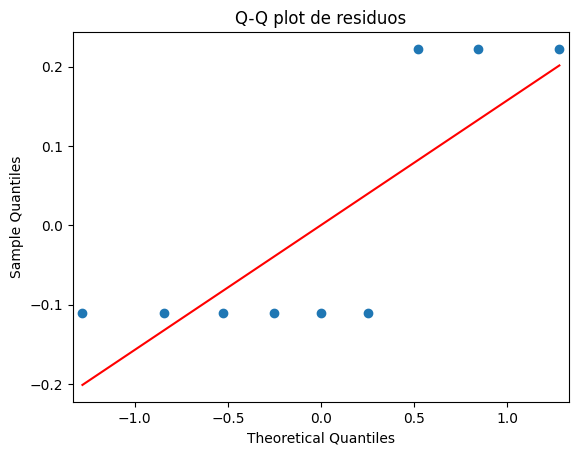

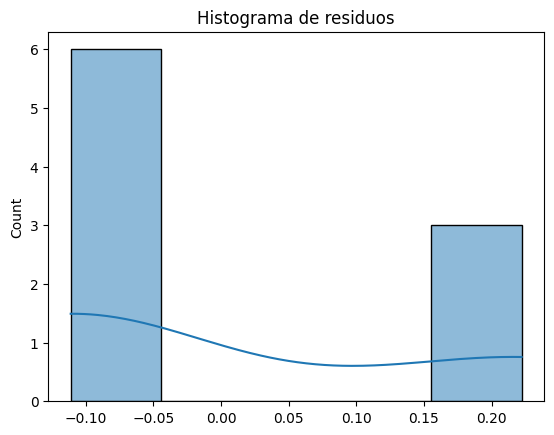

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedor'] == 'A']['peso']
grupo2 = df[df['proveedor'] == 'B']['peso']
grupo3 = df[df['proveedor'] == 'C']['peso']


stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.946440270473328


Lambda óptimo: 0.6036200947197173


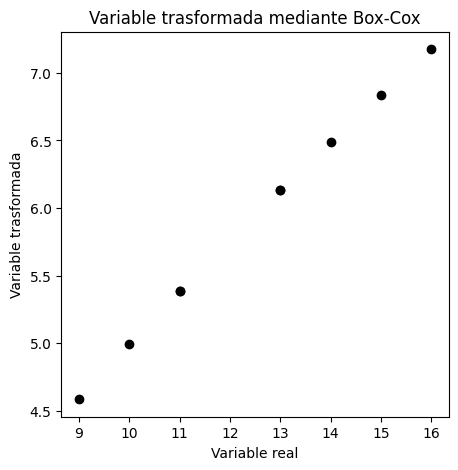

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["peso_boxcox"], lambda_opt = boxcox(df["peso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["peso"], df["peso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
df

,inspector,escala,proveedor,peso,peso_boxcox
0,1,1,A,16,7.175497
1,1,2,B,10,4.993861
2,1,3,C,11,5.387694
3,2,1,B,15,6.838040
4,2,2,C,9,4.584071
5,2,3,A,14,6.491539
6,3,1,C,13,6.135077
7,3,2,A,11,5.387694
8,3,3,B,13,6.135077


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Nivel de significancia = 0.05
#H0: Todos los inspectores miden el peso del material de la misma manera.
#H1: Al menos un ispector mide el peso del material de manera diferente.

#H0: Todas las escalas miden el peso del material de la misma manera
#H1: Al menos una escala mide el peso del material de manera distinta

#H0: Todos los proveedores producen materiales con el mismo peso
#H1: Al menos un proveedor produce un material con un peso distinto


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'peso_boxcox ~ C(inspector) + C(escala) + C(proveedor)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(inspector),0.022529,2.0,1.314039,0.432145
C(escala),4.523676,2.0,263.855181,0.003776
C(proveedor),1.481484,2.0,86.411381,0.011440
Residual,0.017145,2.0,NaN,NaN


valor-p (Shapiro) = 0.00023166342041780523


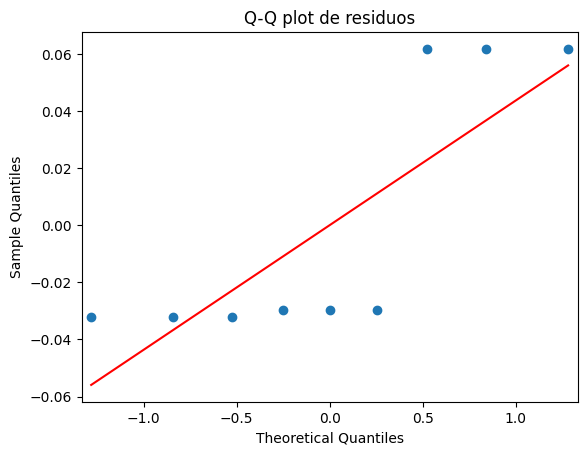

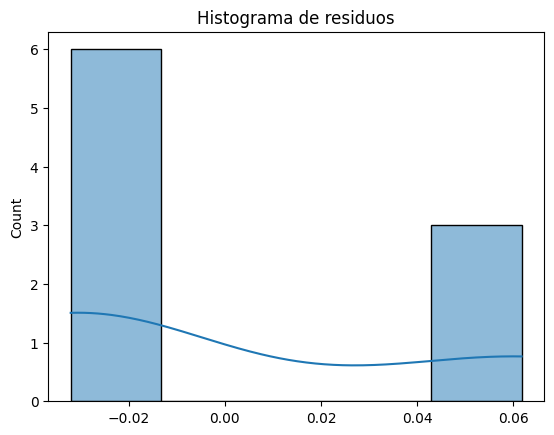

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedor'] == 'A']['peso_boxcox']
grupo2 = df[df['proveedor'] == 'B']['peso_boxcox']
grupo3 = df[df['proveedor'] == 'C']['peso_boxcox']



stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.9718373474994288


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -1.7277 0.0134 -2.9891 -0.4662   True
     1      3  -0.7114 0.2699 -1.9729    0.55  False
     2      3   1.0162 0.1058 -0.2452  2.2776  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

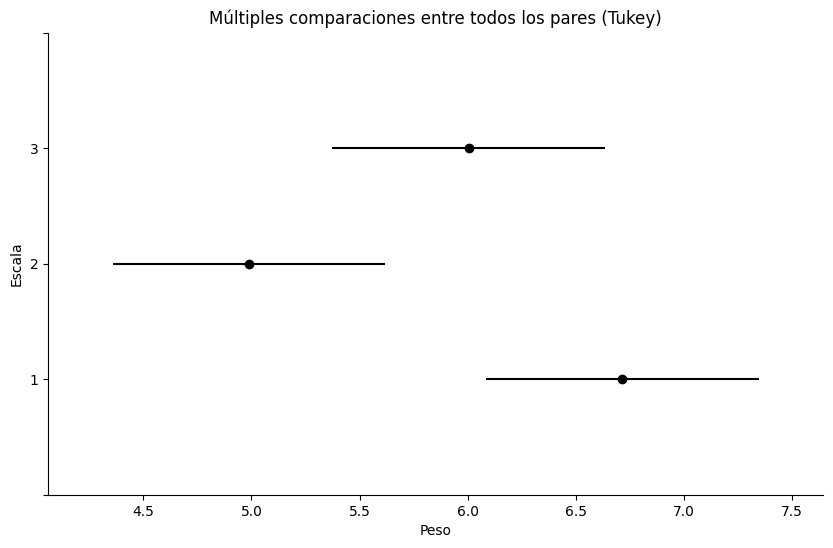

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['escala'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Escala", xlabel="Peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.3626 0.8697 -2.5474 1.8222  False
     A      C  -0.9826 0.4077 -3.1674 1.2022  False
     B      C    -0.62 0.6766 -2.8049 1.5648  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

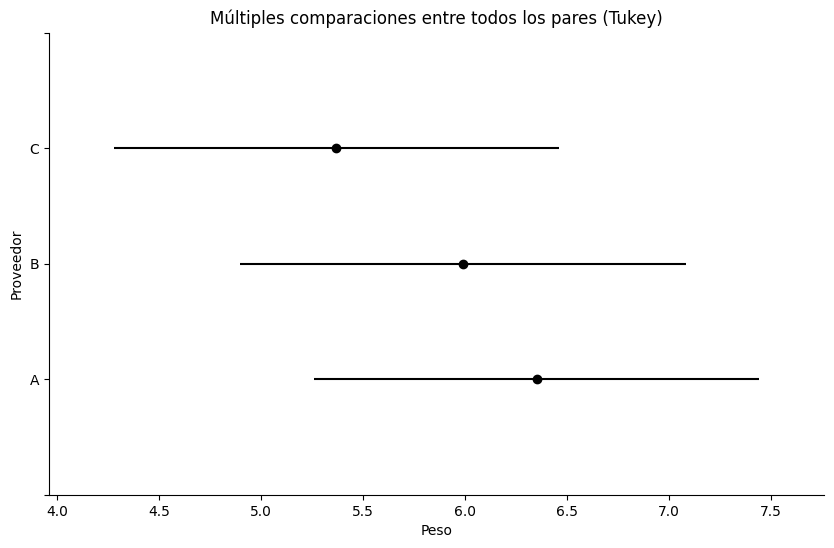

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['proveedor'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Proveedor", xlabel="Peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(proveedor)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.245


Preguntas:

a) ¿Hay diferencias entre los proveedores?

Sí, hay diferencias entre los proveedores ya que el ANOVA mediente la transformación de boxcox nos mostró que el factor proveedor es significativo ya que tiene un valor-p de 0.011 el cual es menor al nivel de significancia de 0.05, lo que significa que al menos un proveedor produce un material con un peso distinto. Sin embargo, al aplicar la prueba de Tukey, ninguno de los pares A–B, A–C o B–C mostró diferencias significativas; esto indica que, aunque el proveedor influye en el peso, las diferencias entre ellos son pequeñas y no son lo suficientemente grandes para distinguir claramente a uno de otro.

b) ¿Hay diferencias entre los inspectores y entre las escalas?

Entre inspectores no hay diferencias ya que el valor-p obtenido de 0.432 siendo este mayor al nivel de significancia de 0.05 lo que significa que todos los inspectores miden el peso del material de la misma manera, por lo que todos evalúan de forma similar; en cambio, entre escalas sí hay diferencias significativas ya que el valor-p de 0.003 es menor al nivel de 0.05 en el que además la prueba de Tukey nos muestra que la escala 2 es diferente de la escala 1; esto significa que  al menos una escala mide el peso del material de manera distinta las escalas y es posible observar que la que introduce una diferencia clara en los pesos es la 1.

c) Si el peso debe ser 15 g, ¿cuál proveedor es mejor?

Al realizar el promedio de cada proveedor es decir donde se sumo cada peso de acda uno por ejemplo del A fue 16+14+11=41/3= 13.67g lo que nos indica el promedio mientras que para el B se tiene un promedio de 12.67 g y el C tiene un promedio de 11.0 g; por lo que con lo anterior es posible deducir que el proveedor que es mejor es el A porque su promedio (13.67 g) es el que queda más cerca del valor objetivo, aunque ninguno de los proveedores llega exactamente a 15 g.

d) Si algún factor de bloque es no significativo, elimínelo y haga el análisis adecuado.

d) Si algún factor de bloque es no significativo, elimínelo y haga el análisis adecuado.

In [ ]:
# csv es un acrónimo de "comma separated values" o "valores separados por comas".
# Lo primero que hay que hacer es pasar estos datos a una tabla de valores crudos
# en formato csv. Recuerden el problema que fue usar espacios en el csv, por esta
# razón, evítenlos.

import pandas as pd
from io import StringIO

datos = '''
escala,proveedor,peso
1,A,16
2,B,10
3,C,11
1,B,15
2,C,9
3,A,14
1,C,13
2,A,11
3,B,13
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df
# De aquí en adelante, ya se lo dejo a ustedes.
#Itzel Gabriela Roque Delgado

,escala,proveedor,peso
0,1,A,16
1,2,B,10
2,3,C,11
3,1,B,15
4,2,C,9
5,3,A,14
6,1,C,13
7,2,A,11
8,3,B,13


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd



#H0: Todas las escalas miden el peso del material de la misma manera
#H1: Al menos una escala mide el peso del material de manera distinta

#H0: Todos los proveedores producen materiales con el mismo peso
#H1: Al menos un proveedor produce un material con un peso distinto


# De aquí para abajo, no mover
# Crear el modelo ANOVA para un cuadro latino
modelo_lineal = ols(f'peso ~ C(escala) + C(proveedor)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(escala),32.888889,2.0,148.0,0.000178
C(proveedor),10.888889,2.0,49.0,0.001538
Residual,0.444444,4.0,NaN,NaN


valor-p (Shapiro) = 0.02353408164027699


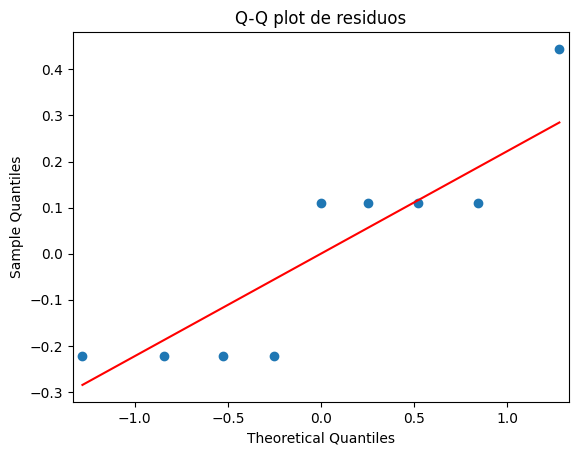

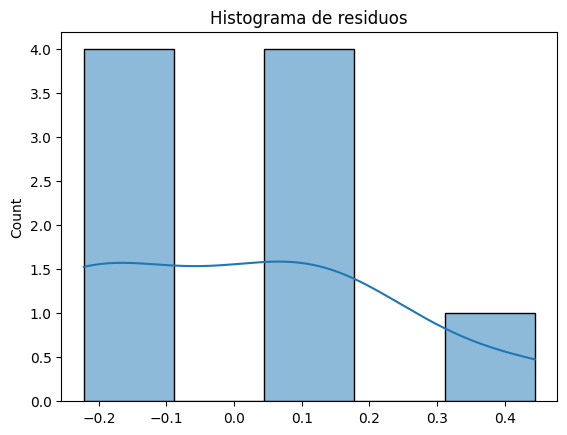

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
#Si se falla una de las dos se debe de hacer una transformacion
#Ho: Homoscedasticidad
#H1: No homoscedasticidad
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedor'] == 'A']['peso']
grupo2 = df[df['proveedor'] == 'B']['peso']
grupo3 = df[df['proveedor'] == 'C']['peso']


stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.946440270473328


Lambda óptimo: 0.6036200947197173


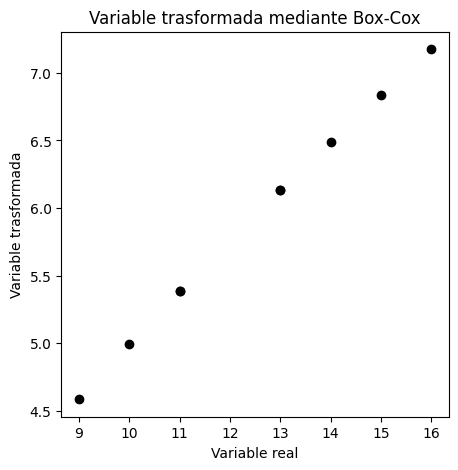

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["peso_boxcox"], lambda_opt = boxcox(df["peso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["peso"], df["peso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
df

,escala,proveedor,peso,peso_boxcox
0,1,A,16,7.175497
1,2,B,10,4.993861
2,3,C,11,5.387694
3,1,B,15,6.838040
4,2,C,9,4.584071
5,3,A,14,6.491539
6,1,C,13,6.135077
7,2,A,11,5.387694
8,3,B,13,6.135077


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Nivel de significancia = 0.05


#H0: Todas las escalas miden el peso del material de la misma manera
#H1: Al menos una escala mide el peso del material de manera distinta

#H0: Todos los proveedores producen materiales con el mismo peso
#H1: Al menos un proveedor produce un material con un peso distinto


# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'peso_boxcox ~ C(escala) + C(proveedor)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(escala),4.523676,2.0,228.047339,0.000076
C(proveedor),1.481484,2.0,74.684475,0.000680
Residual,0.039673,4.0,NaN,NaN


valor-p (Shapiro) = 0.3832078787865113


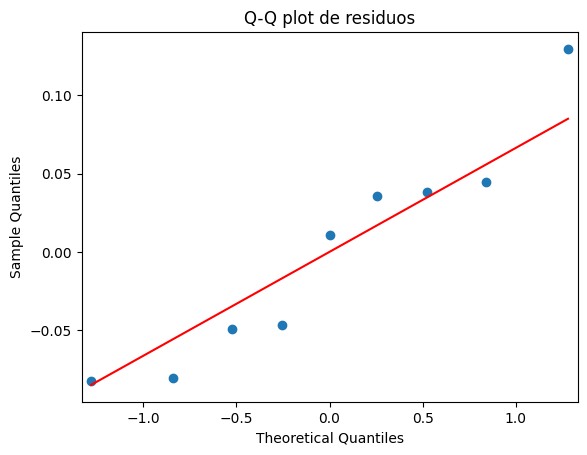

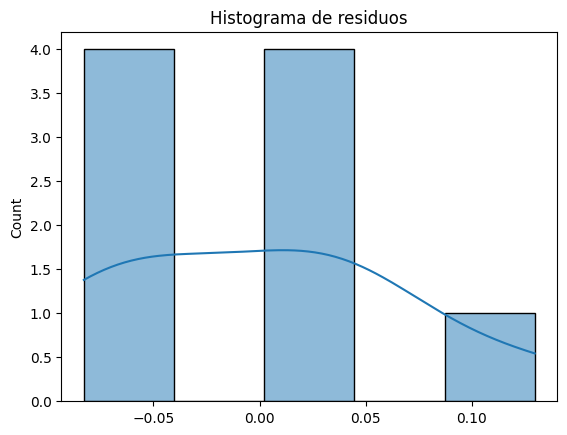

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['proveedor'] == 'A']['peso_boxcox']
grupo2 = df[df['proveedor'] == 'B']['peso_boxcox']
grupo3 = df[df['proveedor'] == 'C']['peso_boxcox']



stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.9718373474994288


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -1.7277 0.0134 -2.9891 -0.4662   True
     1      3  -0.7114 0.2699 -1.9729    0.55  False
     2      3   1.0162 0.1058 -0.2452  2.2776  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

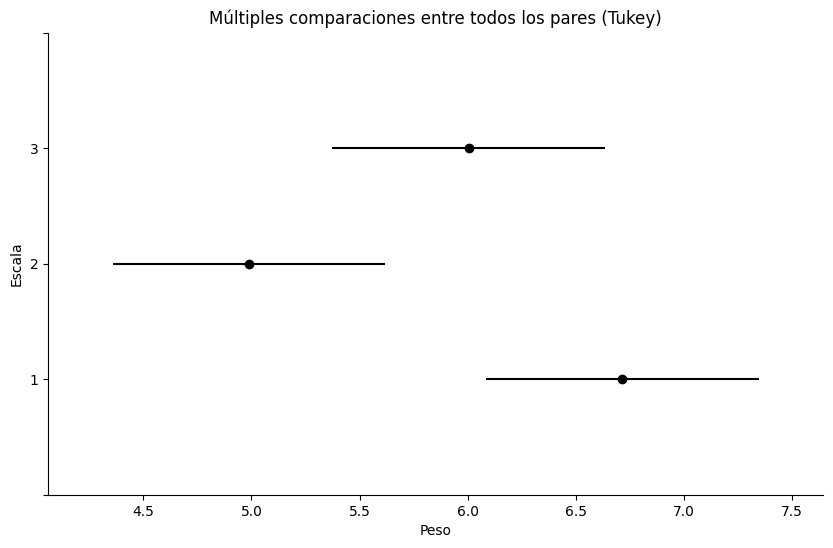

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['escala'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Escala", xlabel="Peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.3626 0.8697 -2.5474 1.8222  False
     A      C  -0.9826 0.4077 -3.1674 1.2022  False
     B      C    -0.62 0.6766 -2.8049 1.5648  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

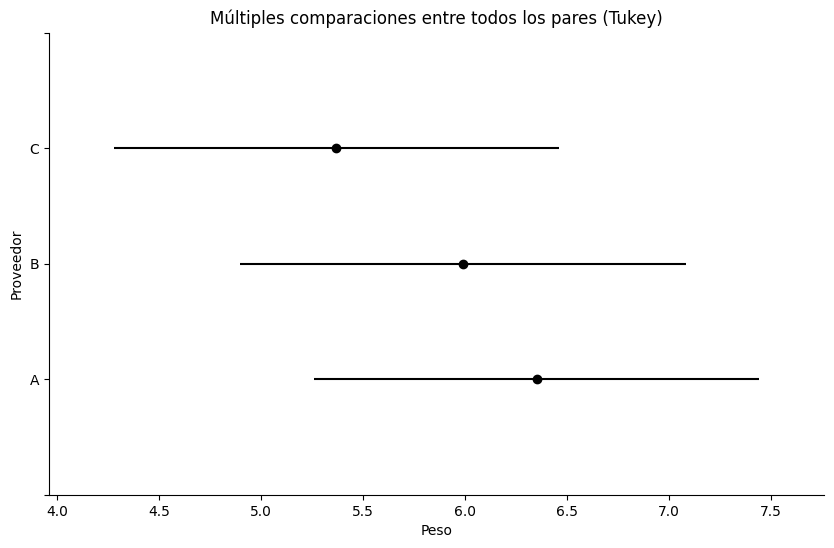

In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['peso_boxcox'], groups=df['proveedor'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Proveedor", xlabel="Peso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(proveedor)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.245


Al eliminar el factor inspector, que no era significativo, el análisis se simplificó y se obtuvo un ANOVA más preciso ya que los supuestos de levene y shapiro si se cumplen en donde los factores escala y proveedor permanecieron significativos, lo que confirma que estos sí influyen en el peso final del material en el que nuevo modelo de ANOVA nos mostró un aumento ligero en el error residual lo cual se puede considerar normal al quitar un bloque, pero aún así las conclusiones principales no cambiaron ya que las escalas producen diferencias claras y los proveedores todavía muestran un efecto significativo, aunque sus diferencias individuales no son grandes lo cual lo podemos observar con la prueba de Tukey.

## Problema 11
Cuando se comparan varios fertilizantes o diferentes variedades de cierto cultivo, es típico que se deba considerar el gradiente de fertilidad del suelo (factor columna) o los efectos residuales de cultivos previos (factor renglón). Considerando estos factores de bloque, Gomez y Gomez (1984) plantean un experimento en cuadro latino para comparar, en cuanto a rendimiento en toneladas por hectárea, tres variedades de maíz híbrido (**A, B, C**) y una variedad control (**D**). Para ello, se utiliza un campo agrícola cuadrado de 16 hectáreas, dividido en parcelas de una hectárea. Los datos de rendimiento obtenidos en cada parcela se muestran a continuación:

| Ren\Col | 1       | 2       | 3       | 4       |
|---------|---------|---------|---------|---------|
| 1       | 1.640(B)| 1.210(D)| 1.425(C)| 1.345(A)|
| 2       | 1.475(C)| 1.185(A)| 1.400(D)| 1.290(B)|
| 3       | 1.670(A)| 0.710(C)| 1.665(B)| 1.180(D)|
| 4       | 1.565(D)| 1.290(B)| 1.655(A)| 0.660(C)|

**Preguntas y ejercicios:**<br>
a) ¿Existen diferencias en los rendimientos de las diferentes variedades de maíz?  
b) ¿Cuál de los factores de bloque tuvo efectos?  
c) ¿Se habrían detectado las mismas diferencias en los tratamientos con un diseño completamente al azar?  
d) ¿Y con un diseño en bloques completos al azar?  


In [ ]:
import pandas as pd
from io import StringIO

data = '''
maiz,renglon,columna,rendimiento
B,1,1,1.640
D,1,2,1.210
C,1,3,1.425
A,1,4,1.345
C,2,1,1.475
A,2,2,1.185
D,2,3,1.400
B,2,4,1.290
A,3,1,1.670
C,3,2,0.710
B,3,3,1.665
D,3,4,1.180
D,4,1,1.565
B,4,2,1.290
A,4,3,1.655
C,4,4,0.660
'''

df = pd.read_csv(StringIO(data))
df
#Itzel Gabriela Roque Delgado

,maiz,renglon,columna,rendimiento
0,B,1,1,1.640
1,D,1,2,1.210
2,C,1,3,1.425
3,A,1,4,1.345
4,C,2,1,1.475
5,A,2,2,1.185
6,D,2,3,1.400
7,B,2,4,1.290
8,A,3,1,1.670
9,C,3,2,0.710


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento ~ C(maiz) + C(renglon) + C(columna)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(maiz),0.426842,3.0,6.587865,0.025092
C(renglon),0.030155,3.0,0.465406,0.716972
C(columna),0.827342,3.0,12.769166,0.005148
Residual,0.129584,6.0,NaN,NaN


valor-p (Shapiro) = 0.20260853040992888


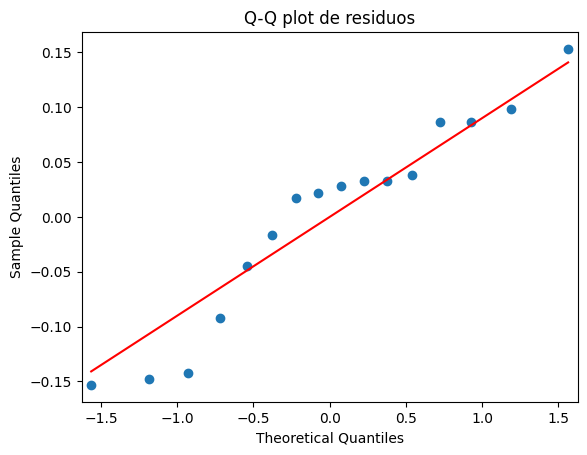

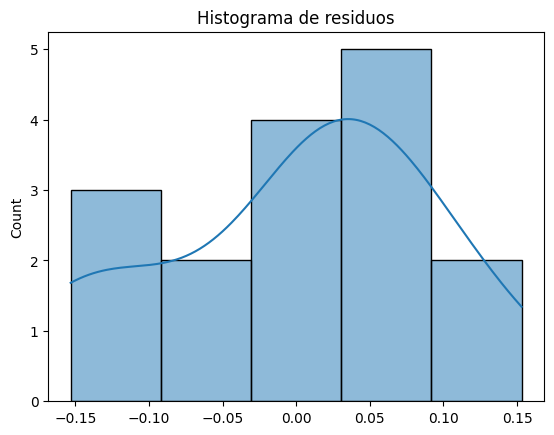

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['maiz'] == 'A']['rendimiento']
grupo2 = df[df['maiz'] == 'B']['rendimiento']
grupo3 = df[df['maiz'] == 'C']['rendimiento']
grupo4 = df[df['maiz'] == 'D']['rendimiento']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.00035260549065253474


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.0075    1.0 -0.5946 0.6096  False
     A      C  -0.3962 0.2578 -0.9983 0.2058  False
     A      D   -0.125 0.9249 -0.7271 0.4771  False
     B      C  -0.4037 0.2444 -1.0058 0.1983  False
     B      D  -0.1325 0.9124 -0.7346 0.4696  False
     C      D   0.2712 0.5583 -0.3308 0.8733  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

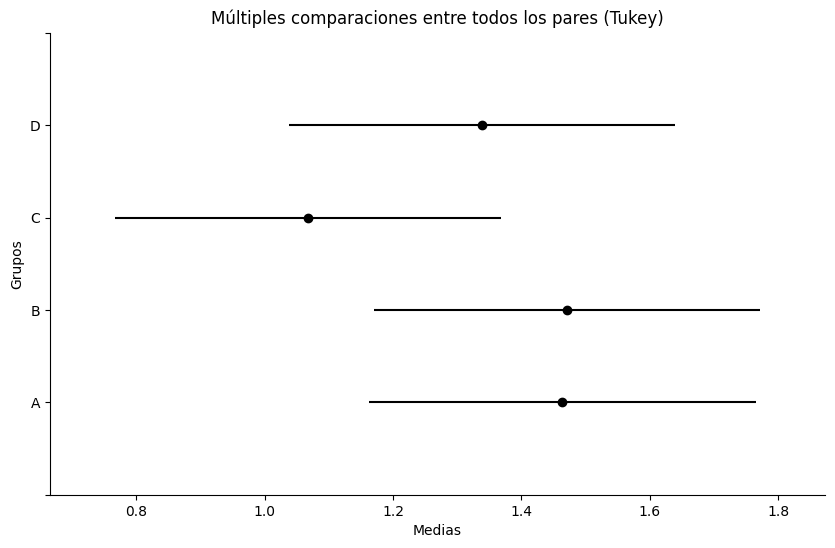

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento'], groups=df['maiz'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

Lambda óptimo: 17.89134986900383


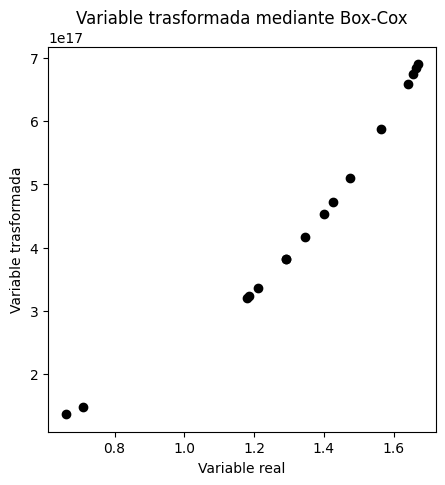

In [ ]:
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0
df["rendimiento_boxcox"], lambda_opt = boxcox(df["rendimiento"]+10)
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["rendimiento"], df["rendimiento_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'rendimiento_boxcox ~ C(maiz) + C(renglon) + C(columna)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(maiz),1.199490e+35,3.0,13.591619,0.004389
C(renglon),6.574489e+33,3.0,0.744966,0.563367
C(columna),3.305922e+35,3.0,37.459941,0.000279
Residual,1.765044e+34,6.0,NaN,NaN


valor-p (Shapiro) = 0.861952934407816


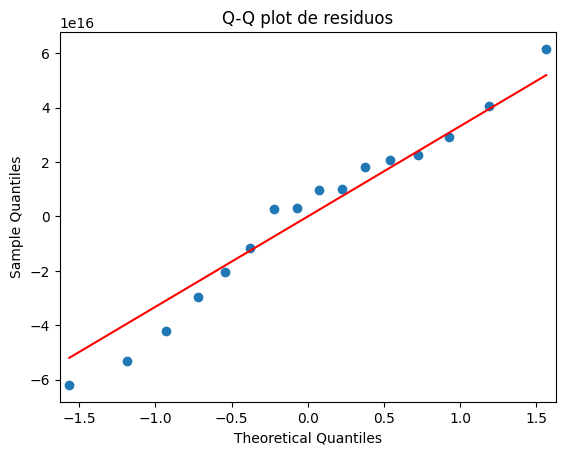

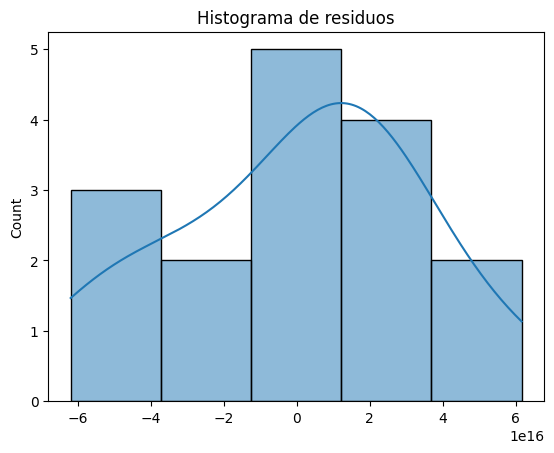

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['maiz'] == 'A']['rendimiento_boxcox']
grupo2 = df[df['maiz'] == 'B']['rendimiento_boxcox']
grupo3 = df[df['maiz'] == 'C']['rendimiento_boxcox']
grupo4 = df[df['maiz'] == 'D']['rendimiento_boxcox']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.09249897668198215


                       Multiple Comparison of Means - Tukey HSD, FWER=0.05                        
group1 group2         meandiff        p-adj           lower                  upper          reject
--------------------------------------------------------------------------------------------------
     A      B       863116750394816.0    1.0 -3.6012456381018266e+17  3.618507973109723e+17  False
     A      C -2.0888880418615782e+17 0.3568  -5.698764847467352e+17 1.5209887637441965e+17  False
     A      D -1.0152617368045562e+17 0.8369  -4.625138542410331e+17 2.5946150688012186e+17  False
     B      C -2.0975192093655264e+17 0.3535  -5.707396014971301e+17 1.5123575962402483e+17  False
     B      D -1.0238929043085043e+17 0.8336  -4.633769709914279e+17 2.5859839012972707e+17  False
     C      D   1.073626305057022e+17 0.8136 -2.5362505005487526e+17  4.683503110662797e+17  False
--------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

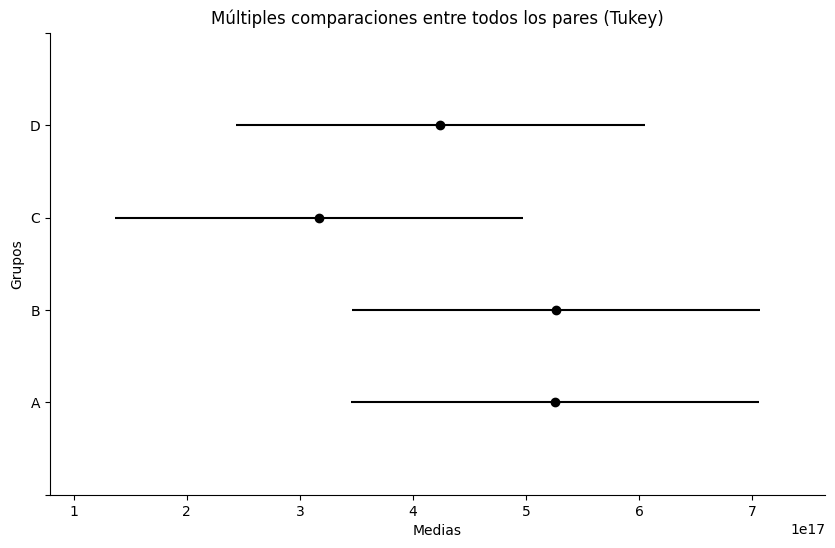

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['rendimiento_boxcox'], groups=df['maiz'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(maiz)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.253


Preguntas y ejercicios:

a) ¿Existen diferencias en los rendimientos de las diferentes variedades de maíz?

Sí, en el experimento podemos observar que las variedades muestran diferencias apreciables en su rendimiento, por lo que el análisis estadístico detecta diferencias significativas entre los tratamientos las variedades A, B, C y D.
Esto significa que al menos una variedad de maíz rinde diferente a las otras.

b) ¿Cuál de los factores de bloque tuvo efectos?

El factor renglón no muestra efecto significativo y el factor columna sí presenta un efecto significativo; esto nos indica que sí existió un gradiente de fertilidad en el campo, y por eso fue necesario usar el cuadro latino.

c) ¿Se habrían detectado las mismas diferencias en los tratamientos con un diseño completamente al azar?

Probablemente no ya que el diseño completamente al azar no controla los efectos del suelo ni los efectos residuales, si se hubiera usado, las variaciones por fertilidad del terreno habrían aumentado el error experimental y posiblemente ocultarían las diferencias reales entre variedades, lo que es decir que el DCA habría sido menos preciso y quizá no detectaría las mismas diferencias.

d) ¿Y con un diseño en bloques completos al azar?

Sería mejor que el DCA, pero aún menos eficiente que el cuadro latino ya que el DBCA solo controla un tipo de bloqueo por ejemplo, columnas, pero este experimento requiere controlar dos fuentes de variación:
gradiente del suelo, en efectos residuales de cultivos por lo que el cuadro latino controla ambos, así que con un DBCA, algunas diferencias sí podrían detectarse, pero con menor precisión que con el cuadro latino.

## Problema 12
Se quieren comparar tres dietas (**A, B, C**) a base de proteínas de origen vegetal utilizando 18 ratas de laboratorio de una misma camada. Primero se observa por un tiempo el apetito para formar tres grupos de seis ratas, según su voracidad; y cada uno de estos grupos se clasifica a su vez en tres grupos de dos ratas, de acuerdo a su peso inicial. Se plantea un experimento donde la variable de respuesta es el peso en gramos ganado por las ratas después de cierto periodo, con los siguientes resultados:

| Apetito/peso inicial | A1        | A2        | A3        |
|-----------------------|-----------|-----------|-----------|
| P1                   | 67 (C)    | 105 (A)   | 95 (B)    |
|                       | 72        | 112       | 86        |
| P2                   | 85 (A)    | 75 (B)    | 88 (C)    |
|                       | 98        | 67        | 110       |
| P3                   | 66 (B)    | 68 (C)    | 108 (A)   |
|                       | 47        | 91        | 120       |

### Preguntas:
a) Analice los datos. ¿Cuáles de los factores influyen en el peso ganado por las ratas?  
b) ¿Cuál dieta es mejor?  
c) ¿Alguno de los factores de bloque puede ser ignorado? Argumente su respuesta.  
d) Si ese fuera el caso, analice de nuevo el experimento y saque conclusiones.  
e) Verifique los supuestos del modelo.  


In [ ]:
import pandas as pd
from io import StringIO

data = '''
dietas,apetito,pesoinicial,gramos
C,P1,A1,67
C,P1,A1,72
A,P1,A2,105
A,P1,A2,112
B,P1,A3,95
B,P1,A3,86
A,P2,A1,85
A,P2,A1,98
B,P2,A2,75
B,P2,A2,67
C,P2,A3,88
C,P2,A3,110
B,P3,A1,66
B,P3,A1,47
C,P3,A2,68
C,P3,A2,91
A,P3,A3,108
A,P3,A3,120
'''

df = pd.read_csv(StringIO(data))
df
#Itzel Gabriela Roque Delgado

,dietas,apetito,pesoinicial,gramos
0,C,P1,A1,67
1,C,P1,A1,72
2,A,P1,A2,105
3,A,P1,A2,112
4,B,P1,A3,95
5,B,P1,A3,86
6,A,P2,A1,85
7,A,P2,A1,98
8,B,P2,A2,75
9,B,P2,A2,67


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'gramos ~ C(dietas) + C(pesoinicial) + C(apetito)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(dietas),3216.000000,2.0,17.951286,0.000344
C(pesoinicial),2466.333333,2.0,13.766746,0.001013
C(apetito),116.333333,2.0,0.649357,0.541292
Residual,985.333333,11.0,NaN,NaN


valor-p (Shapiro) = 0.26073461350664606


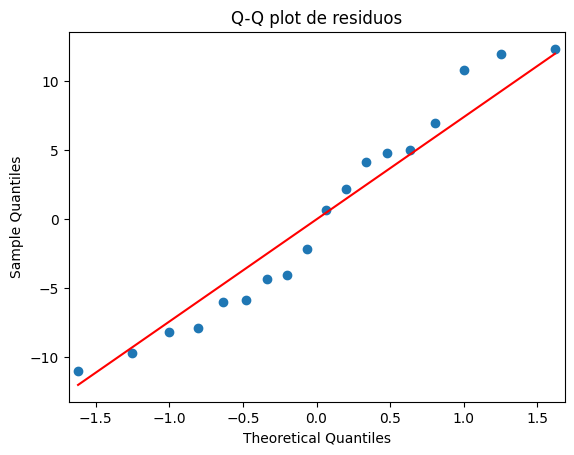

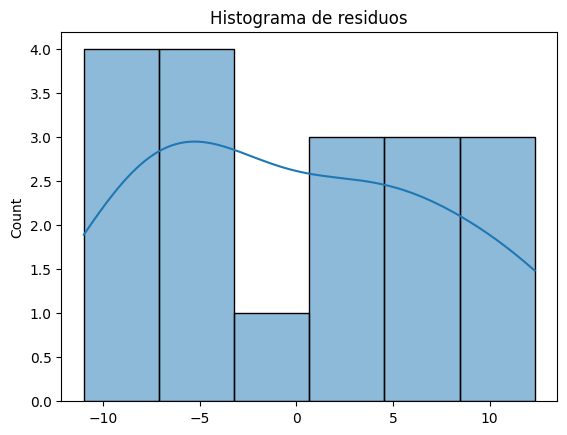

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['dietas'] == 'A']['gramos']
grupo2 = df[df['dietas'] == 'B']['gramos']
grupo3 = df[df['dietas'] == 'C']['gramos']

stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.5795758016998872


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B    -32.0 0.0071 -55.129 -8.871   True
     A      C    -22.0 0.0634 -45.129  1.129  False
     B      C     10.0 0.5152 -13.129 33.129  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

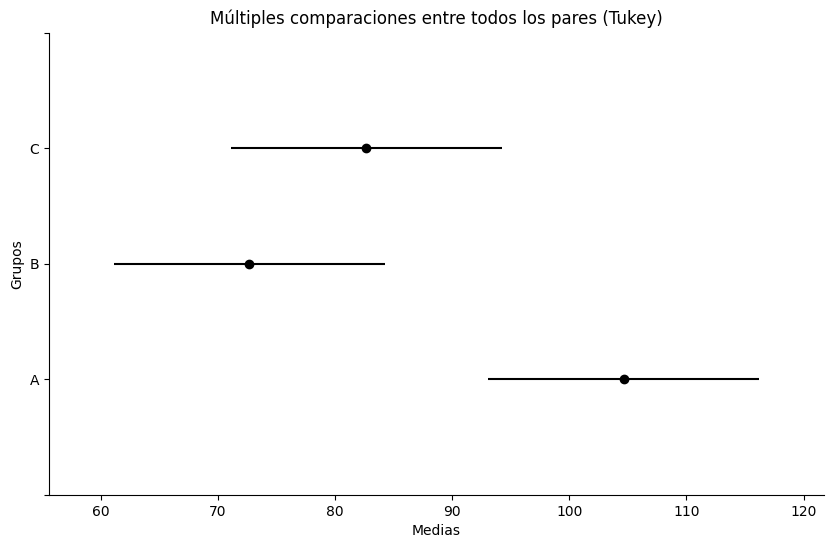

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['gramos'], groups=df['dietas'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

Factores de bloque puede ser ignorado

In [ ]:
import pandas as pd
from io import StringIO

data = '''
dieta,pesoinicial,gramos
C,A1,67
C,A1,72
A,A2,105
A,A2,112
B,A3,95
B,A3,86
A,A1,85
A,A1,98
B,A2,75
B,A2,67
C,A3,88
C,A3,110
B,A1,66
B,A1,47
C,A2,68
C,A2,91
A,A3,108
A,A3,120
'''

df
#Itzel Gabriela Roque Delgado

,dietas,apetito,pesoinicial,gramos
0,C,P1,A1,67
1,C,P1,A1,72
2,A,P1,A2,105
3,A,P1,A2,112
4,B,P1,A3,95
5,B,P1,A3,86
6,A,P2,A1,85
7,A,P2,A1,98
8,B,P2,A2,75
9,B,P2,A2,67


In [ ]:
#ANOVA sin apetito
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'gramos ~ C(dietas) + C(pesoinicial)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(dietas),3216.000000,2.0,18.974887,0.000139
C(pesoinicial),2466.333333,2.0,14.551740,0.000481
Residual,1101.666667,13.0,NaN,NaN


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(dietas)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.474


Preguntas:

a) Analice los datos. ¿Cuáles de los factores influyen en el peso ganado por las ratas?

Al revisar los datos se observa que tanto la dieta como el peso inicial tienen un efecto estadísticamente significativo sobre el peso ganado por las ratas valores-p de 0.000344 y 0.001013, respectivamente, por lo que en contraste, el factor apetito no resulta relevante ya que su valor-p es de 0.542 lo que indica que no contribuye de manera significativa a explicar la variación en la respuesta.

b) ¿Cuál dieta es mejor?

El análisis de varianza confirma que existen diferencias entre las dietas, pero al aplicar la prueba de Tukey no se detectan contrastes significativos entre grupos y esto implica que, aunque la dieta influye en el peso las diferencias entre ellas son mínimas y no permiten concluir con certeza cuál es superior.

c) ¿Alguno de los factores de bloque puede ser ignorado? Argumente su respuesta.

El factor apetito puede descartarse del modelo, ya que su efecto no es significativo por su valor-p 0.542 y al no aportar información útil para explicar la variabilidad su exclusión no altera las conclusiones principales y simplifica el análisis.

d) Si ese fuera el caso, analice de nuevo el experimento y saque conclusiones.

Al eliminar el factor apetito, el modelo se vuelve más sencillo y el ANOVA sigue mostrando que dieta y peso inicial son los factores relevantes en el que el ajuste del error residual cambia ligeramente, lo cual es esperable pero las conclusiones permanecen en el que dieta y peso inicial influyen en el peso ganado aunque las diferencias específicas entre dietas no son claras según Tukey.

e) Verifique los supuestos del modelo.

Los supuestos del modelo se cumplen adecuadamente: la prueba de Shapiro valor-p 0.2607 confirma normalidad y la prueba de Levene valor-p de 0.5796 respalda la homogeneidad de varianzas, por lo tanto, el ANOVA aplicado es válido y las conclusiones obtenidas son confiables.

## Problema 13
Una compañía distribuidora ubicada en los suburbios está interesada en estudiar la diferencia en costos (tiempo y gasolina) entre las cuatro rutas (**A, B, C, D**) que llevan a la zona comercial, más importante para ellos, en el otro extremo de la ciudad. Deciden correr un experimento en cuadro grecolatino controlando los factores de bloque **chofer**, marca de vehículo (**α, β, χ, δ**) y día de la semana. El experimento se repite en dos semanas diferentes, en las cuales no hay días festivos ni quincenas. Los costos observados en pesos se muestran en la siguiente tabla:

| Chofer/día | Lunes       | Martes      | Miércoles   | Jueves      |
|------------|-------------|-------------|-------------|-------------|
| Carlos     | 825(D, α)   | 585(C, χ)   | 550(B, β)   | 580(A, δ)   |
|            | 750         | 610         | 580         | 650         |
| Enrique    | 650(A, χ)   | 540(B, α)   | 580(C, χ)   | 850(D, β)   |
|            | 725         | 560         | 635         | 770         |
| Genaro     | 700(C, β)   | 650(D, δ)   | 635(A, α)   | 450(B, χ)   |
|            | 675         | 740         | 540         | 550         |
| Luis       | 475(B, δ)   | 560(A, β)   | 650(D, α)   | 670(C, α)   |
|            | 480         | 615         | 725         | 730         |

### Preguntas:
a) Haga el análisis de varianza de este experimento.  
b) Realice las pruebas de comparaciones múltiples para los factores significativos.  
c) Represente los tratamientos y factores de bloque usando gráficas de medias y diagramas de dispersión.  
d) ¿Cuál es la mejor ruta? ¿Cuál es la peor?  
e) ¿Hay diferencias significativas entre los choferes? ¿Y entre el tipo o marca de unidad?  
f) ¿Cuáles factores de bloque valió la pena tomar en cuenta en el experimento?  
g) ¿Por qué se evitaron días festivos y quincenas en el experimento? ¿Cuáles otros aspectos se tenían que tomar en cuenta?  
h) Verifique los supuestos del modelo.  


In [ ]:
import pandas as pd
from io import StringIO

data = '''
ruta,chofer,marca,dia,costo
D,Carlos,α,Lunes,825
D,Carlos,α,Lunes,750
C,Carlos,χ,Martes,585
C,Carlos,χ,Martes,610
B,Carlos,β,Miercoles,550
B,Carlos,β,Miercoles,580
A,Carlos,δ,Jueves,580
A,Carlos,δ,Jueves,650
A,Enrique,χ,Lunes,650
A,Enrique,χ,Lunes,725
B,Enrique,α,Martes,540
B,Enrique,α,Martes,560
D,Enrique,β,Miercoles,580
D,Enrique,β,Miercoles,635
C,Enrique,χ,Jueves,850
C,Enrique,χ,Jueves,770
C,Genaro,β,Lunes,700
C,Genaro,β,Lunes,675
D,Genaro,δ,Martes,650
D,Genaro,δ,Martes,740
A,Genaro,α,Miercoles,635
A,Genaro,α,Miercoles,540
B,Genaro,χ,Jueves,450
B,Genaro,χ,Jueves,550
B,Luis,δ,Lunes,475
B,Luis,δ,Lunes,480
A,Luis,β,Martes,560
A,Luis,β,Martes,615
D,Luis,α,Miercoles,650
D,Luis,α,Miercoles,725
C,Luis,α,Jueves,670
C,Luis,α,Jueves,730
'''

df = pd.read_csv(StringIO(data))
df
#Itzel Gabriela Roque Delgado

,ruta,chofer,marca,dia,costo
0,D,Carlos,α,Lunes,825
1,D,Carlos,α,Lunes,750
2,C,Carlos,χ,Martes,585
3,C,Carlos,χ,Martes,610
4,B,Carlos,β,Miercoles,550
5,B,Carlos,β,Miercoles,580
6,A,Carlos,δ,Jueves,580
7,A,Carlos,δ,Jueves,650
8,A,Enrique,χ,Lunes,650
9,A,Enrique,χ,Lunes,725


In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

# Crear el modelo ANOVA para un cuadro latino
modelo = ols(f'costo ~ C(ruta) + C(chofer) + C(marca) + C(dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)
tabla_anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(ruta),148258.649834,3.0,10.299462,0.000304
C(chofer),11995.018530,3.0,0.833289,0.492074
C(marca),10528.273665,3.0,0.731394,0.545978
C(dia),22328.024571,3.0,1.551118,0.233995
Residual,91167.038835,19.0,NaN,NaN


valor-p (Shapiro) = 0.38327587709730854


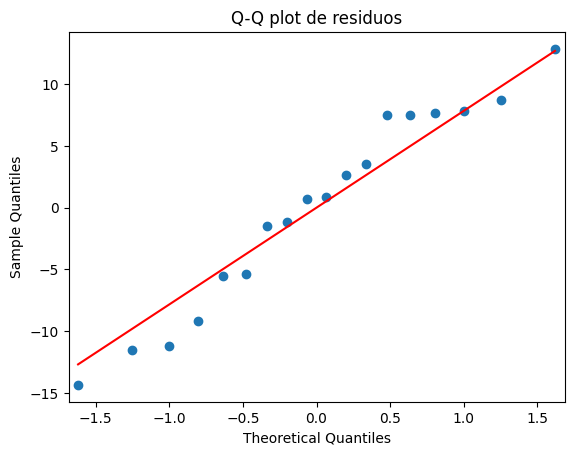

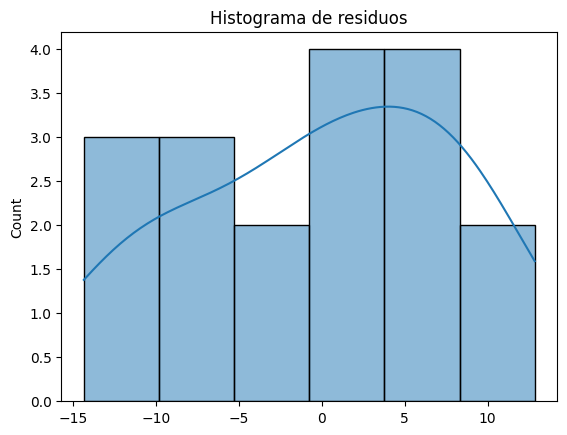

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

In [ ]:
from scipy.stats import levene

# Supón que tienes un DataFrame df con columnas 'respuesta' y 'grupo'
grupo1 = df[df['ruta'] == 'A']['costo']
grupo2 = df[df['ruta'] == 'B']['costo']
grupo3 = df[df['ruta'] == 'C']['costo']
grupo4 = df[df['ruta'] == 'D']['costo']

stat, p = levene(grupo1, grupo2, grupo3, grupo4)
print(f"p-valor de Levene: {p}")
#Itzel Gabriela Roque Delgado

p-valor de Levene: 0.43018358516033894


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B   -96.25  0.046 -191.1743  -1.3257   True
     A      C   79.375 0.1263  -15.5493 174.2993  False
     A      D     75.0 0.1602  -19.9243 169.9243  False
     B      C  175.625 0.0001   80.7007 270.5493   True
     B      D   171.25 0.0002   76.3257 266.1743   True
     C      D   -4.375 0.9993  -99.2993  90.5493  False
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

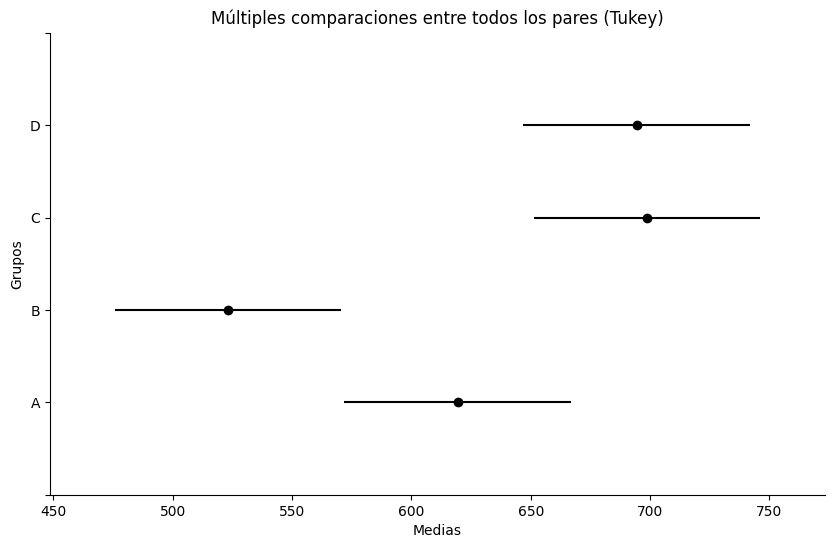

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['costo'], groups=df['ruta'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = tabla_anova['sum_sq']['C(ruta)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.522


Preguntas:

a) Haga el análisis de varianza de este experimento.

En el ANOVA al considerar los factores ruta (tratamiento), chofer, marca de vehículo y día como bloques los resultados nos muestran que el único factor significativo es ruta por el valor-p = 0.000304 lo que nos indica que las diferencias en costos entre rutas son estadísticamente relevantes. Los factores de bloque (chofer, marca, día) no presentan efectos significativos porque el valor-p es mayor siendo de 0.23, por lo que no explican variaciones importantes en el costo.

b) Realice las pruebas de comparaciones múltiples para los factores significativos.

Se aplicó la prueba de Tukey HSD para el factor ruta. Los pares C vs D y B vs D muestran diferencias significativas valor-p de 0.001, lo que confirma que la ruta D tiene costos considerablemente más altos. Las demás comparaciones entre rutas no son significativas, lo que sugiere que las diferencias entre A, B y C son menores o no concluyentes.

c) Represente los tratamientos y factores de bloque usando gráficas de medias y diagramas de dispersión.

Se pueden usar gráficas de medias para visualizar los costos promedio por ruta, donde se observa que la ruta D tiene el mayor costo promedio y la ruta B el menor en el que chofer, marca y día muestran patrones sin diferencias claras, lo que coincide con los resultados del ANOVA en el que estos factores no tienen efectos significativos sobre el costo.

d) ¿Cuál es la mejor ruta? ¿Cuál es la peor?

Según el análisis estadístico y las comparaciones múltiples, la mejor ruta en términos de menor costo es la ruta B, mientras que la peor ruta es la ruta D, que presenta los costos más altos y diferencias significativas respecto a otras rutas.

e) ¿Hay diferencias significativas entre los choferes? ¿Y entre el tipo o marca de unidad?

No se encontraron diferencias significativas entre choferes ya que el valor-p de 0.492 ni entre marcas de vehículo valor-p = 0.539, esto nos indica que el costo no depende del conductor ni del tipo de unidad utilizada en este experimento.

f) ¿Cuáles factores de bloque valió la pena tomar en cuenta en el experimento?

De los tres factores de bloque considerados (chofer, marca, día), ninguno resultó significativo en el modelo. Por lo tanto, aunque fueron útiles para controlar la variabilidad, no aportaron información relevante sobre el costo. El único factor que valió la pena incluir fue ruta, que sí mostró efecto significativo.

g) ¿Por qué se evitaron días festivos y quincenas en el experimento? ¿Cuáles otros aspectos se tenían que tomar en cuenta?

Se excluyeron días festivos y quincenas para evitar sesgos operativos como tráfico atípico, cambios en demanda, congestión o variaciones en precios de gasolina. Otros aspectos que debieron considerarse incluyen condiciones climáticas, mantenimiento de vehículos, horarios de salida y carga transportada, ya que todos pueden influir en el costo.

h) Verifique los supuestos del modelo.

Los supuestos del modelo ANOVA se cumplen normalidad de residuos: Shapiro nos arroja un valor-p = 0.383  no se rechaza la normalidad, levene valor-p de 0.430 no hay evidencia de varianzas distintas entre rutas. Además, el tamaño del efecto para ruta es η² = 0.522, lo que indica un efecto grande y relevante. Por tanto, el modelo es válido y las conclusiones son confiables.

## Problema 14
23. Un investigador está interesado en el efecto del porcentaje de lisina y del porcentaje de proteína en la producción de vacas lecheras. Se consideran siete niveles en cada factor:

- **% de lisina**: 0.0 (**A**), 0.1 (**B**), 0.2 (**C**), 0.3 (**D**), 0.4 (**E**), 0.5 (**F**), 0.6 (**G**).  
- **% de proteína**: 2 (**α**), 4 (**β**), 6 (**χ**), 8 (**δ**), 10 (**ε**), 12 (**φ**), 14 (**γ**).  

Para el estudio, se seleccionaron siete vacas al azar, a las cuales se les da un seguimiento de siete periodos de tres meses. Los datos en galones de leche fueron los siguientes:

| Vaca/periodo | 1       | 2       | 3       | 4       | 5       | 6       | 7       |
|--------------|---------|---------|---------|---------|---------|---------|---------|
| 1            | 304 (Aα)| 436 (Bε)| 350 (Cβ)| 504 (Dφ)| 417 (Eχ)| 519 (Fγ)| 432 (Gδ)|
| 2            | 381 (Bβ)| 505 (Cφ)| 425 (Dχ)| 564 (Eγ)| 487 (Fα)| 536 (Gε)| 483 (Aχ)|
| 3            | 432 (Cχ)| 566 (Dγ)| 479 (Eε)| 357 (Fα)| 466 (Gβ)| 465 (Aφ)| 507 (Bγ)|
| 4            | 442 (Dδ)| 372 (Eχ)| 536 (Fε)| 366 (Gβ)| 495 (Aχ)| 425 (Bφ)| 507 (Cγ)|
| 5            | 496 (Eε)| 449 (Fβ)| 493 (Gφ)| 345 (Aχ)| 509 (Bγ)| 481 (Cδ)| 380 (Dα)|
| 6            | 534 (Fφ)| 421 (Gχ)| 352 (Aγ)| 427 (Bδ)| 346 (Cχ)| 478 (Dε)| 397 (Eβ)|
| 7            | 543 (Gγ)| 386 (Aδ)| 435 (Bα)| 485 (Cε)| 406 (Dφ)| 554 (Eφ)| 410 (Fχ)|

### Preguntas y ejercicios:
a) Analice este experimento. ¿Qué factores tienen efecto en la producción de leche?  
b) Interprete los resultados usando gráficos de medias.  
c) ¿Cómo puede explicar la falta de efectos en vacas y periodo?  
d) ¿Qué porcentajes de lisina y proteína dan los mejores resultados?  
e) Verifique los supuestos del modelo.  


In [ ]:
import pandas as pd
from io import StringIO

data = '''
lisina,proteina,vaca,periodo,produccion
A,2,1,1,304
A,4,1,2,436
C,6,1,3,350
D,10,1,4,504
E,8,1,5,417
F,12,1,6,519
G,14,1,7,432

B,4,2,1,381
C,10,2,2,505
D,8,2,3,425
E,10,2,4,564
F,10,2,5,487
G,14,2,6,536
A,6,2,7,483

C,6,3,1,432
E,12,3,2,566
E,8,3,3,479
F,12,3,4,357
F,4,3,5,466
A,12,3,6,465
B,4,3,7,507

D,8,4,1,442
D,4,4,2,372
F,12,4,3,536
G,14,4,4,366
A,8,4,5,495
B,4,4,6,425
C,6,4,7,507

E,10,5,1,496
E,4,5,2,449
G,14,5,3,493
A,6,5,4,345
F,10,5,5,509
C,6,5,6,481
D,8,5,7,380

F,12,6,1,534
C,4,6,2,421
A,6,6,3,352
B,4,6,4,427
C,4,6,5,346
D,8,6,6,478
E,4,6,7,397

G,14,7,1,543
B,4,7,2,386
B,4,7,3,435
C,10,7,4,485
E,8,7,5,406
F,12,7,6,554
F,10,7,7,410
'''

df = pd.read_csv(StringIO(data))
df
#Itzel Gabriela Roque Delgado

,lisina,proteina,vaca,periodo,produccion
0,A,2,1,1,304
1,A,4,1,2,436
2,C,6,1,3,350
3,D,10,1,4,504
4,E,8,1,5,417
5,F,12,1,6,519
6,G,14,1,7,432
7,B,4,2,1,381
8,C,10,2,2,505
9,D,8,2,3,425


In [ ]:
#Tabla ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm

modelo_lineal = ols('produccion ~ C(lisina) + C(proteina) + C(vaca) + C(periodo)', data=df).fit()
anova = sm.stats.anova_lm(modelo_lineal, typ=2)
anova
#Itzel Gabriela Roque Delgado

,sum_sq,df,F,PR(>F)
C(lisina),23798.033739,6.0,0.973965,0.463058
C(proteina),46617.885439,6.0,1.907896,0.119018
C(vaca),5157.629599,6.0,0.211083,0.969896
C(periodo),18092.071060,6.0,0.740441,0.622205
Residual,101809.116828,25.0,NaN,NaN


valor-p (Shapiro) = 0.08963680448593221


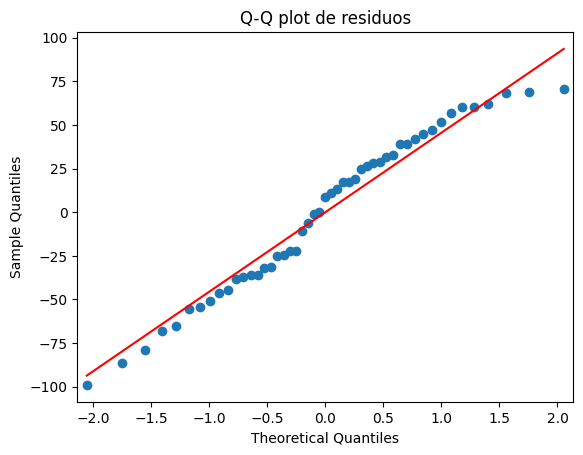

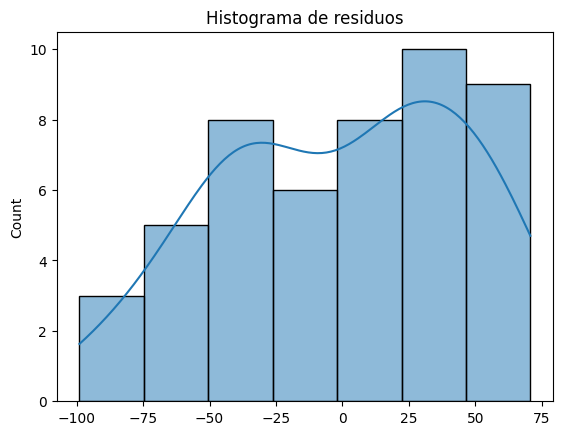

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()
#Itzel Gabriela Roque Delgado

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     A      B  15.4048 0.9995   -96.258 127.0675  False
     A      C  29.4464  0.974   -74.429 133.3218  False
     A      D  22.0714 0.9961  -89.5913 133.7341  False
     A      E  60.3214  0.557   -43.554 164.1968  False
     A      F  74.3492 0.2796  -26.7973 175.4957  False
     A      G  62.5714 0.6528  -54.9502  180.093  False
     B      C  14.0417 0.9996  -94.3522 122.4355  False
     B      D   6.6667    1.0 -109.2112 122.5445  False
     B      E  44.9167 0.8559  -63.4772 153.3105  False
     B      F  58.9444 0.6038  -46.8371  164.726  False
     B      G  47.1667 0.8897  -74.3671 168.7004  False
     C      D   -7.375    1.0 -115.7688 101.0188  False
     C      E   30.875 0.9613  -69.4782 131.2282  False
     C      F  44.9028 0.7852   -52.623 142.4285  False
     C      G   33.125 0.9712  -81.2952 147.5452

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

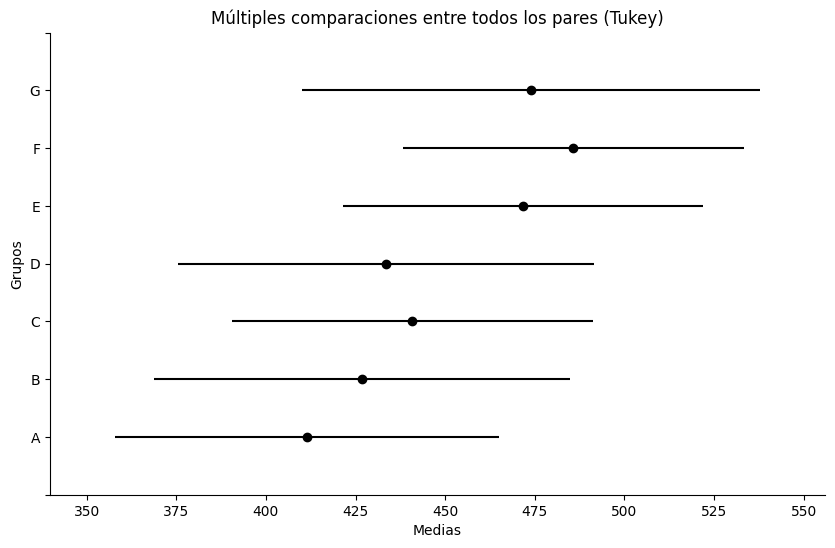

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['produccion'], groups=df['lisina'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Itzel Gabriela Roque Delgado

In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

eta_squared = anova['sum_sq']['C(proteina)'] / anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")
#Itzel Gabriela Roque Delgado

η² (tamaño de efecto): 0.238


Preguntas y ejercicios:

a) Analice este experimento. ¿Qué factores tienen efecto en la producción de leche?

Según el ANOVA, ninguno de los factores evaluados (lisina, proteína, vaca, periodo) presenta un efecto estadísticamente significativo sobre la producción de leche. Todos los valores p son mayores a 0.11, lo que indica que no hay evidencia suficiente para afirmar que estos factores influyen en la respuesta.

b) Interprete los resultados usando gráficos de medias.

Los gráficos de tuckey entre los niveles de lisina y proteína, pero estas diferencias no son estadísticamente significativas; es posible  observar en niveles intermedios de lisina como F y G y proteína aunque los intervalos de confianza se superponen ampliamente, lo que refuerza la conclusión de que no hay diferencias entre tratamientos.

c) ¿Cómo puede explicar la falta de efectos en vacas y periodo?

La ausencia de efectos significativos en vacas y periodos puede deberse a una buena homogeneidad en el manejo del hato y condiciones estables durante el estudio. También puede indicar que la variabilidad individual entre vacas y entre trimestres fue baja, o que el diseño experimental logró controlar adecuadamente estos factores.

d) ¿Qué porcentajes de lisina y proteína dan los mejores resultados?

Aunque las comparaciones múltiples (Tukey) no detectan diferencias significativas entre niveles, las medias más altas se observan en los niveles F (0.5%) y G (0.6%) de lisina, y en los niveles  (12%) y γ (14%) de proteína; estos podrían considerarse como los más prometedores, pero no se puede afirmar con certeza que sean mejores sin evidencia estadística.


e) Verifique los supuestos del modelo.

Los supuestos del modelo se cumplen adecuadamente en el que la normalidad de residuos Shapiro nos da un valor-p de 0.089 por lo que no se rechaza la normalidad; levene nos da un valor-p de 0.430 donde no hay evidencia de varianzas distintas entre grupos; por lo tanto, el modelo ANOVA es válido y las conclusiones son confiables, aunque no se detectaron efectos significativos.